In [21]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import scipy
#import gseapy
from anndata import AnnData
import matplotlib.pyplot as plt

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
#sc.logging.print_versions()

# In/Out

In [22]:
out_folder = 'C:/Users/aamw4/home/aamw4/results/'
#Data = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/mixl_chim_atlas.h5"
#Results = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/data/mixl_chim_atlas_analysis_anna.h5"

#gene_conversion = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/gene_id_name_conversion.csv"

In [23]:
sc.settings.set_figure_params(dpi=80, dpi_save=300)

In [24]:
adata = sc.read_h5ad('C:/Users/aamw4/home/aamw4/mixl_chim_atlas.h5')

In [25]:
adata_wt = ad.read_loom('C:/Users/aamw4/home/aamw4/wt_chim_atlas_analysis.h5')

In [16]:
adata.X.todense()

matrix([[2.72901427, 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.92171784, 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [1.68832075, 0.        , 1.68832075, ..., 0.        , 0.        ,
         0.        ],
        ...,
        [1.13217799, 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [1.98099249, 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [2.68863848, 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ]])

In [17]:
adata_wt.X.todense()

matrix([[2.8927681 , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.9794731 , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [1.6802996 , 0.        , 1.6802996 , ..., 0.        , 0.        ,
         0.        ],
        ...,
        [1.804091  , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [1.2890933 , 0.        , 1.05853   , ..., 0.        , 0.        ,
         0.        ],
        [1.8933574 , 0.        , 0.53853613, ..., 0.        , 0.        ,
         0.        ]], dtype=float32)

In [14]:
adata.X

<153520x31217 sparse matrix of type '<class 'numpy.float64'>'
	with 531618311 stored elements in Compressed Sparse Row format>

In [5]:
#adata_wt = sc.read_loom("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/wildtype_injection/chimera-wt/adata_wt.h5")

In [ ]:
#adata_wt = sc.read_loom("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/wildtype_injection/chimera-wt/data/wt_chim_atlas_analysis.h5")

/home/aamw4/miniconda3/envs/myenv/lib/python3.7/site-packages/numba/np/ufunc/parallel.py:363: NumbaWarning: The TBB threading layer requires TBB version 2019.5 or later i.e., TBB_INTERFACE_VERSION >= 11005. Found TBB_INTERFACE_VERSION = 9106. The TBB threading layer is disabled.
  warnings.warn(problem)


In [7]:
#adata_wt.obs.to_csv("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/wildtype_injection/chimera-wt/data/wt_chim_atlas_analysis.csv")

In [1]:
#useful before we had the wt_adata
#adata_wt.obs = pd.read_csv("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/wildtype_injection/chimera-wt/data/big_meta_mapping+haem+meso+gut.csv", index_col=3)

NameError: name 'pd' is not defined

In [8]:
np.unique(adata.obs.tdTom)

array(['nan', 'neg', 'pos'], dtype=object)

In [26]:
#subsetting only the chimera cells = won't need atlas cells for now
    
adata = adata[adata.obs_names.str.startswith('chim'),:].copy()

In [65]:
adata_wt = adata_wt[adata_wt.obs_names.str.startswith('wt'),:].copy()

In [6]:
print(adata.shape)
adata[1:10,1:10]
adata.var_names_make_unique()
adata

(37208, 31217)


AnnData object with n_obs × n_vars = 37208 × 31217
    obs: 'sample', 'stage', 'barcode', 'sequencing.batch', 'stripped', 'doublet', 'theiler', 'doub.density', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'weight', 'stage.mapped', 'celltype.mapped', 'closest.cell', 'sizeFactor', 'tdTom'
    obsm: 'X_pca'
    layers: 'logcounts'

In [66]:
print(adata_wt.shape)
#adata[1:10,1:10]
adata_wt.var_names_make_unique()
adata_wt.obs.index

(13481, 29453)


Index(['wt_cell_1-1', 'wt_cell_2-1', 'wt_cell_3-1', 'wt_cell_4-1',
       'wt_cell_5-1', 'wt_cell_6-1', 'wt_cell_7-1', 'wt_cell_8-1',
       'wt_cell_9-1', 'wt_cell_10-1',
       ...
       'wt_cell_13472-1', 'wt_cell_13473-1', 'wt_cell_13474-1',
       'wt_cell_13475-1', 'wt_cell_13476-1', 'wt_cell_13477-1',
       'wt_cell_13478-1', 'wt_cell_13479-1', 'wt_cell_13480-1',
       'wt_cell_13481-1'],
      dtype='object', length=13481)

In [83]:
#adata Mixl1 chimera
# add gut clusters
gut_subclust = pd.read_csv('C:/Users/aamw4/home/aamw4/Mixl1/big_meta_mapping.tab', '\t')
gut_subclust = gut_subclust[['cell', 'gut_subclust.mapped']]
adata.obs = adata.obs.merge(gut_subclust, on='cell', how='left')
adata.obs = adata.obs.set_index('cell', drop=True)

# add haem clusters
haem_subclust = pd.read_csv('C:/Users/aamw4/home/aamw4/big_meta_mapping.tab', '\t')
haem_subclust = haem_subclust[['cell', 'haem_subclust.mapped']]
adata.obs = adata.obs.merge(haem_subclust, on='cell', how='left')
adata.obs = adata.obs.set_index('cell', drop=True)


# add meso clusters
meso_subclust = pd.read_csv('C:/Users/aamw4/home/aamw4/big_meta_mapping+meso3.tab', '\t')
meso_subclust = meso_subclust[['cell', 'meso.mapped']]
adata.obs = adata.obs.merge(meso_subclust, on='cell', how='left')
adata.obs = adata.obs.set_index('cell', drop=True)

C:\Users\aamw4\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3146: DtypeWarning: Columns (7,13,14,19) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,
AnnData expects .obs.index to contain strings, but your first indices are: Int64Index([0, 1], dtype='int64'), …
C:\Users\aamw4\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3146: DtypeWarning: Columns (7,13,14,19,22,27,29,30,31,32,33,34,37) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,
AnnData expects .obs.index to contain strings, but your first indices are: Int64Index([0, 1], dtype='int64'), …


In [98]:
gut_subclust = pd.read_csv('C:/Users/aamw4/home/aamw4/Mixl1/big_meta_mapping.tab', '\t')
gut_subclust = gut_subclust[['cell', 'gut_subclust.mapped']]
adata.obs = adata.obs.merge(gut_subclust, on='cell', how='left')
adata.obs = adata.obs.set_index('cell', drop=True)

AnnData expects .obs.index to contain strings, but your first indices are: Int64Index([0, 1], dtype='int64'), …


In [103]:
adata.obs['gut_subclust.mapped']

cell
chim_cell_1        NaN
chim_cell_2        NaN
chim_cell_3        NaN
chim_cell_4        NaN
chim_cell_5        NaN
                  ... 
chim_cell_43819    NaN
chim_cell_43821    NaN
chim_cell_43822    NaN
chim_cell_43824    NaN
chim_cell_43825    NaN
Name: gut_subclust.mapped, Length: 37208, dtype: object

In [ ]:
#subsetting only the chimera cells = won't need atlas cells for now
    
adata_wt = adata_wt[adata_wt.obs_names.str.startswith('wt'),:].copy()

print(adata_wt.shape)
adata_wt[1:10,1:10]
adata_wt.var_names_make_unique()
adata_wt

In [67]:
#adata_wt WT chimera
string = '-1'
# add gut clusters
wt_tab = pd.read_csv('C:/Users/aamw4/home/aamw4/big_meta_mapping+haem+meso+gut.tab', '\t')
gut_subclust = wt_tab[['cell', 'gut_subclust.mapped']]
gut_subclust.cell = [cell + string for cell in gut_subclust.cell]
gut_subclust.index = gut_subclust.cell
adata_wt.obs = pd.merge(adata_wt.obs, gut_subclust, left_index=True, right_index=True)
#adata.obs = adata.obs.set_index('cell', drop=True)

# add haem clusters
#haem_subclust = pd.read_csv('C:/Users/aamw4/home/aamw4/big_meta_mapping+haem+meso+gut.tab', '\t')
haem_subclust = wt_tab[['cell', 'haem_subclust.mapped']]
haem_subclust.cell = [cell + string for cell in haem_subclust.cell]
haem_subclust.index = haem_subclust.cell
adata_wt.obs = pd.merge(adata_wt.obs, haem_subclust, left_index=True, right_index=True)
#adata.obs = adata.obs.set_index('cell', drop=True)


# add meso clusters
#meso_subclust = pd.read_csv('C:/Users/aamw4/home/aamw4/big_meta_mapping+haem+meso+gut.tab', '\t')
meso_subclust = wt_tab[['cell', 'meso.mapped']]
meso_subclust.cell = [cell + string for cell in meso_subclust.cell]
meso_subclust.index = meso_subclust.cell
adata_wt.obs = pd.merge(adata_wt.obs, meso_subclust, left_index=True, right_index=True)
#adata.obs = adata.obs.set_index('cell', drop=True)

In [68]:
adata.var_names #alias for .var.index


Index(['mt-Cytb', 'mt-Nd6', 'mt-Nd5', 'mt-Nd4', 'mt-Nd4l', 'mt-Nd3', 'mt-Co3',
       'mt-Atp6', 'mt-Atp8', 'mt-Co2',
       ...
       'Impact', 'Dsg3', 'Fam13b', 'Rprd1a', 'Taf4b', 'Zfp521', 'Hrh4', 'Dsc1',
       'Psma8', '2700062C07Rik'],
      dtype='object', length=27917)

In [84]:
adata.obs['haem_subclust.mapped'] = adata.obs['haem_subclust.mapped'].astype(str)

np.unique(adata.obs['haem_subclust.mapped'])

array(['BP1', 'BP2', 'BP3', 'BP4', 'EC8', 'Ery1', 'Ery2', 'Ery3', 'Ery4',
       'Haem2', 'Haem3', 'Haem4', 'Mk', 'My', 'nan'], dtype=object)

In [69]:
adata_wt.obs['haem_subclust.mapped'] = adata_wt.obs['haem_subclust.mapped'].astype(str)

np.unique(adata_wt.obs['haem_subclust.mapped'])

array(['BP1', 'BP2', 'BP3', 'BP4', 'EC1', 'EC2', 'EC3', 'EC4', 'EC5',
       'EC6', 'EC7', 'EC8', 'Ery1', 'Ery2', 'Ery3', 'Ery4', 'Haem1',
       'Haem2', 'Haem3', 'Haem4', 'Mes1', 'Mes2', 'Mk', 'My', 'nan'],
      dtype=object)

# trying to convert ensemble_ID to gene_ID

In [71]:
#df = pd.read_csv("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/data/ensembl_gene_table_81.txt", delim_whitespace=True, header=None, skiprows=1, names=['Ensembl Gene ID','Associated Gene Name','Gene type']) #without naming header, didn't work
#df.columns
df = pd.read_csv("C:/Users/aamw4/home/aamw4/ensembl_gene_table_81.txt", header=0, sep='\t', index_col=0)
df

,Associated Gene Name,Gene type
Ensembl Gene ID,,
ENSMUSG00000064372,mt-Tp,Mt_tRNA
ENSMUSG00000064371,mt-Tt,Mt_tRNA
ENSMUSG00000064370,mt-Cytb,protein_coding
ENSMUSG00000064369,mt-Te,Mt_tRNA
ENSMUSG00000064368,mt-Nd6,protein_coding
...,...,...
ENSMUSG00000097611,RP24-152F23.3,protein_coding
ENSMUSG00000107101,RP23-465P18.1,antisense
ENSMUSG00000097395,RP24-152F23.5,protein_coding


In [28]:
list_names = [name for name in list(df.index) if name in adata.var_names]

In [29]:
adata =  adata[:,list_names].copy()

In [30]:
adata.var_names = list(df.loc[list_names]['Associated Gene Name'])

In [31]:
adata.var_names_make_unique()

In [32]:
adata.var_names

Index(['mt-Cytb', 'mt-Nd6', 'mt-Nd5', 'mt-Nd4', 'mt-Nd4l', 'mt-Nd3', 'mt-Co3',
       'mt-Atp6', 'mt-Atp8', 'mt-Co2',
       ...
       'Impact', 'Dsg3', 'Fam13b', 'Rprd1a', 'Taf4b', 'Zfp521', 'Hrh4', 'Dsc1',
       'Psma8', '2700062C07Rik'],
      dtype='object', length=27917)

In [72]:
list_names = [name for name in list(df.index) if name in adata_wt.var_names]

adata_wt =  adata_wt[:,list_names].copy()

adata_wt.var_names = list(df.loc[list_names]['Associated Gene Name'])

adata_wt.var_names_make_unique()

adata_wt.var_names

Index(['mt-Cytb', 'mt-Nd6', 'mt-Nd5', 'mt-Nd4', 'mt-Nd4l', 'mt-Nd3', 'mt-Co3',
       'mt-Atp6', 'mt-Atp8', 'mt-Co2',
       ...
       'Impact', 'Dsg3', 'Fam13b', 'Rprd1a', 'Taf4b', 'Zfp521', 'Hrh4', 'Dsc1',
       'Psma8', '2700062C07Rik'],
      dtype='object', length=27151)

In [78]:
adata_wt8 = adata_wt[adata_wt.obs['stage'] == 'E8.5',:]

In [79]:
adata_wt8

View of AnnData object with n_obs × n_vars = 3531 × 27151
    obs: 'barcode', 'batch', 'cell_x', 'celltype', 'celltype.mapped', 'closest.cell', 'cluster', 'cluster.stage', 'cluster.sub', 'cluster.theiler', 'colour', 'doub.density', 'doublet', 'endo_gephiX', 'endo_gephiY', 'endo_gutCluster', 'endo_gutDPT', 'endo_gutX', 'endo_gutY', 'endo_trajectoryDPT', 'endo_trajectoryName', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'sample', 'sequencing.batch', 'sizeFactor', 'stage', 'stage.mapped', 'stripped', 'tdTom', 'theiler', 'umapX', 'umapY', 'cell_y', 'gut_subclust.mapped', 'cell_x', 'haem_subclust.mapped', 'cell_y', 'meso.mapped'
    obsm: 'X_pca', 'X_umap'
    layers: 'logcounts'

# subsetting for celltype.mapped with more than 50 cells per condition

In [33]:
df = pd.crosstab(adata.obs['celltype.mapped'], adata.obs['tdTom'])
df

tdTom,neg,pos
celltype.mapped,,
Allantois,738,2143
Anterior Primitive Streak,1,0
Blood progenitors 1,56,71
Blood progenitors 2,210,250
Cardiomyocytes,691,534
Caudal Mesoderm,59,94
Caudal epiblast,4,3
Caudal neurectoderm,1,0
Def. endoderm,97,347


In [125]:
df = pd.crosstab(adata.obs['celltype.mapped'], adata.obs['tdTom'])
vec = np.array((df.neg>=50) & (df.pos>=50))
print(vec)
df_good = df.loc[vec] #df.iloc[vec] does not work for one reason I don't understand, but df.loc[voc] takes away index
print(df_good)
print(df_good.dtypes)

[ True False  True  True  True  True False False  True False  True  True
  True False False  True  True  True False  True  True False  True  True
 False False  True False  True False  True  True  True False]
tdTom                          neg   pos
celltype.mapped                         
Allantois                      738  2143
Blood progenitors 1             56    71
Blood progenitors 2            210   250
Cardiomyocytes                 691   534
Caudal Mesoderm                 59    94
Def. endoderm                   97   347
Erythroid1                     467   674
Erythroid2                    1881   614
Erythroid3                    1427    91
ExE mesoderm                   874  2103
Forebrain/Midbrain/Hindbrain  2641  2696
Gut                            929   173
Intermediate mesoderm          505  1120
Mesenchyme                     188   452
NMP                            960  1089
Neural crest                   832   575
Paraxial mesoderm             1351  1255
Pharyngeal me

# DE by Wilcoxon ranking

In [126]:
def create_tuple_for_for_columns(df_a, multi_level_col):
    """
    Create a columns tuple that can be pandas MultiIndex to create multi level column

    :param df_a: pandas dataframe containing the columns that must form the first level of the multi index
    :param multi_level_col: name of second level column
    :return: tuple containing (second_level_col, firs_level_cols)
    """
    temp_columns = []
    for item in df_a.columns:
        temp_columns.append((multi_level_col, item))
    return temp_columns

In [29]:
sc.settings.figdir = '/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plots/heatmaps/'
ran = range(0,200)
df_dea = pd.DataFrame().reindex(ran) #initialization of df_dea #ValueError: Cannot set a frame with no defined index and a value that cannot be converted to a Series
df_dea.dropna(inplace=True)
number_genes = []


for pop in list(df_good.index):
    print(pop)
    adata_rid = adata[adata.obs['celltype.mapped'] == pop,:].copy()
    sc.tl.rank_genes_groups(adata_rid, groupby='tdTom', groups=['pos','neg'], method='wilcoxon', n_genes=10000, key = "wilcoxon")
    df1 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['names'])
    df2 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['pvals_adj'])
    df3 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['logfoldchanges'])
    df4 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['scores'])

    
    vec_up = np.where((df3['pos']>=np.log2(1.5)) & (df2['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
    vec_down = np.where((df3['neg']>= np.log2(1.5)) & (df2['neg']<= 0.1) )[0]
    
        
    df_pos = pd.DataFrame(df2.loc[vec_up]['pos'])
    df_pos.index = list(df1.loc[vec_up]['pos'])
    df_pos['lfc'] = list(df3.loc[vec_up]['pos'])
    df_pos = df_pos.sort_values(by='lfc',ascending=False)

 
    df_neg = pd.DataFrame(df2.loc[vec_down]['neg'])
    df_neg.index = list(df1.loc[vec_down]['neg'])
    df_neg['lfc'] = list(df3.loc[vec_down]['neg'])
    df_neg = df_neg.sort_values(by='lfc',ascending=False)

 
    lista_n = df_neg.index
    lista_p = df_pos.index
 
    print(len(lista_p))
    print(len(lista_n))
    
    number_pos = len(lista_p)
    number_neg = len(lista_n)
    
    number_genes.append(number_pos)
    number_genes.append(number_neg)
    
    #make a list with lengths of all lists, sort and take maximum
    
    list_pos = lista_p.tolist() #format to list to add to dataframe
    list_neg = lista_n.tolist()
    
    ##create df_dea with gene names, pvaladj and lfc
           
    df_dea[pop + '_pos_g'] = pd.Series(list_pos) #to avoid errors from different lengths, convert to Series
    df_dea[pop + '_pos_pvaladj'] = pd.Series(list(df_pos['pos']))
    df_dea[pop + '_pos_lfc'] = pd.Series(list(df_pos['lfc']))
    
    
    df_dea[pop + '_neg_g'] = pd.Series(list_neg)
    df_dea[pop + '_neg_pvaladj'] = pd.Series(list(df_neg['neg']))
    df_dea[pop + '_neg_lfc'] = pd.Series(list(df_neg['lfc']))
    
        
print('finished ranking genes')
number_genes.sort(reverse=True)
number_genes[0] #prints highest number of selected genes for any celltype population to adapt range accordingly of df-Dea in initialisation

Allantois
ranking genes


... storing 'gut_subclust.mapped' as categorical
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:05)
38
94
Blood progenitors 1
ranking genes


... storing 'gut_subclust.mapped' as categorical
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
3
12
Blood progenitors 2
ranking genes


...

... storing 'gut_subclust.mapped' as categorical
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:03)
14
22
Surface ectoderm
ranking genes


... storing 'gut_subclust.mapped' as categorical
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:04)
26
30
finished ranking genes


173

In [30]:
df_dea.to_csv(out_folder + 'chim_DEGs_df_dea')

In [31]:
adata_rid.uns["rank_genes_groups"]["names"]

rec.array([('Erdr1', 'Rpl21'), ('Kcnq1ot1', 'Hbb-y'), ('Impact', 'Grb10'),
           ..., ('AU016765', 'Gm11520'), ('Gm15348', 'Gm17322'),
           ('Gm20641', 'Ldb1')],
          dtype=[('pos', 'O'), ('neg', 'O')])

In [59]:
output_dr = 'C:/Users/aamw4/home/aamw4/plots/MAplots/'

Allantois


ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical
... storing 'gut_subclust.mapped' as categorical
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:06)


38
94


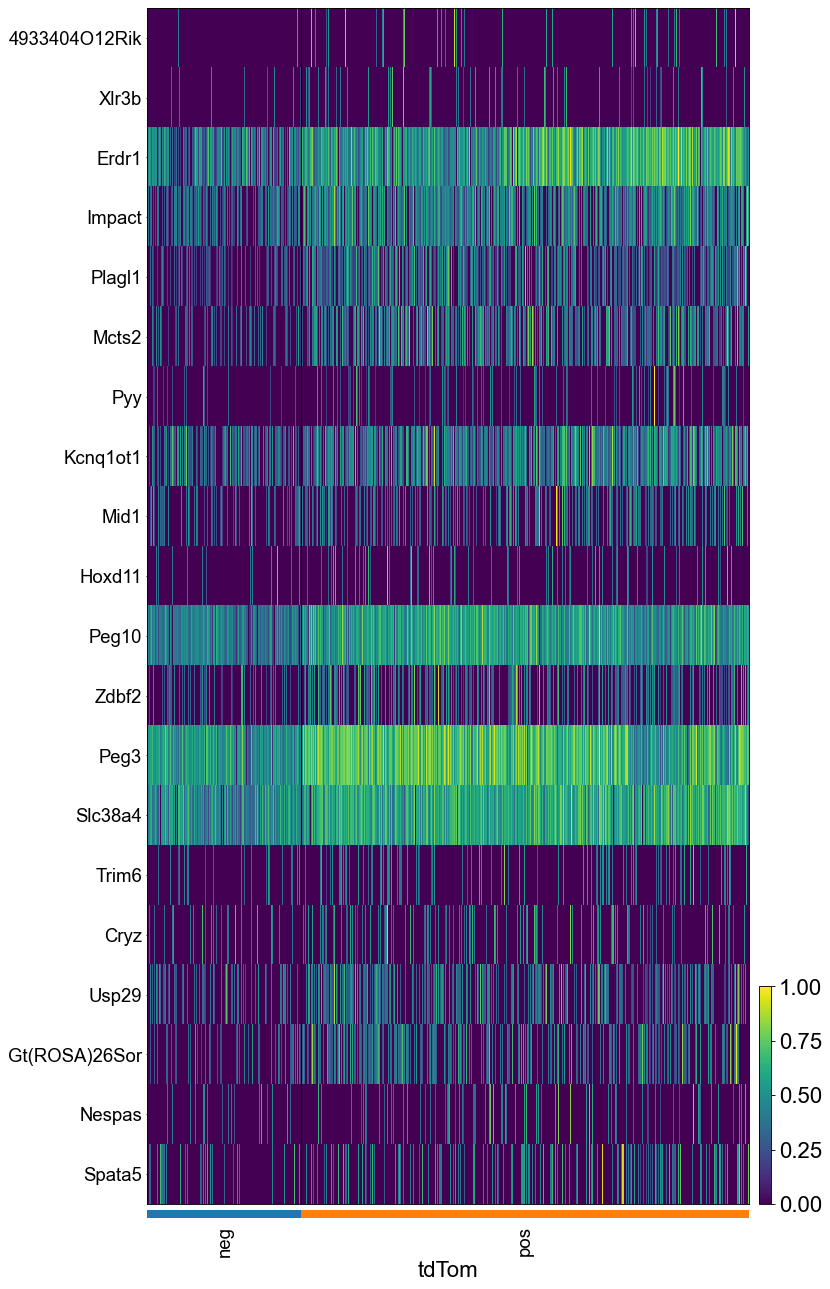

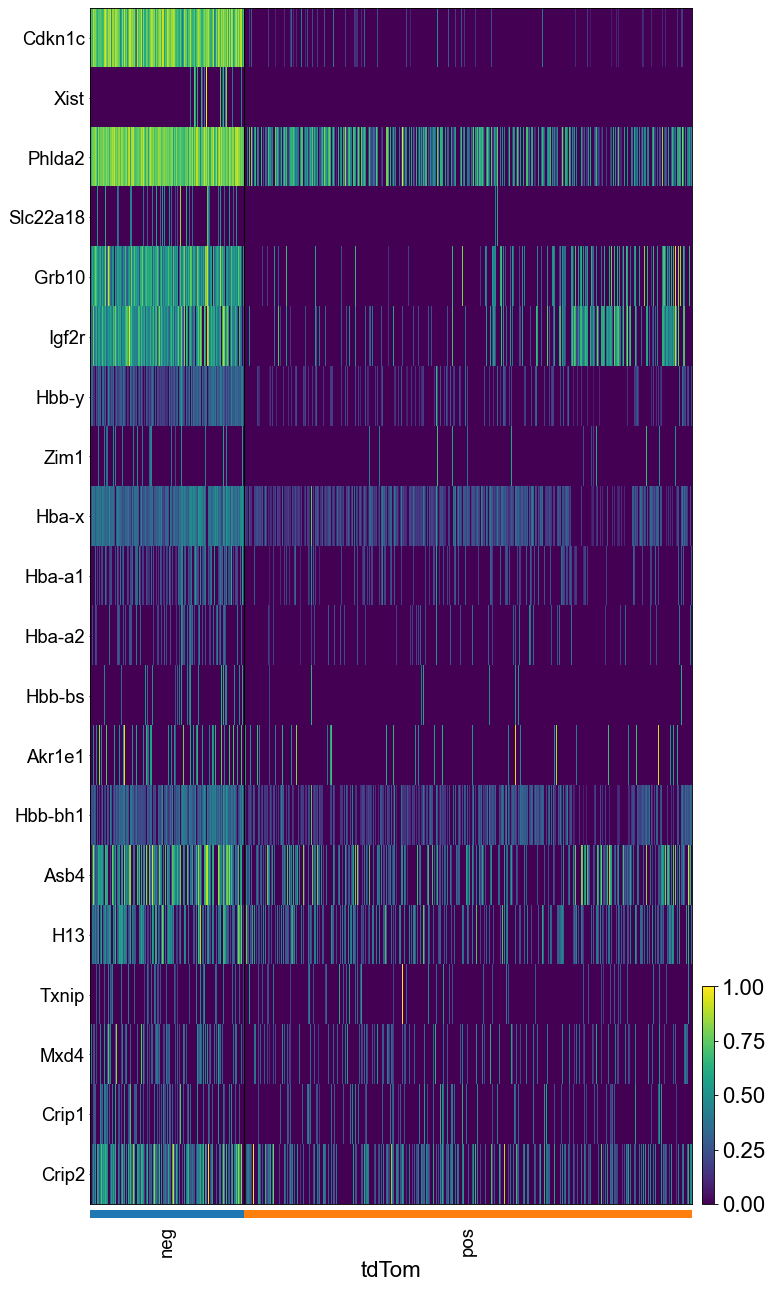

ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical
... storing 'gut_subclust.mapped' as categorical


Blood progenitors 1


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


3
12


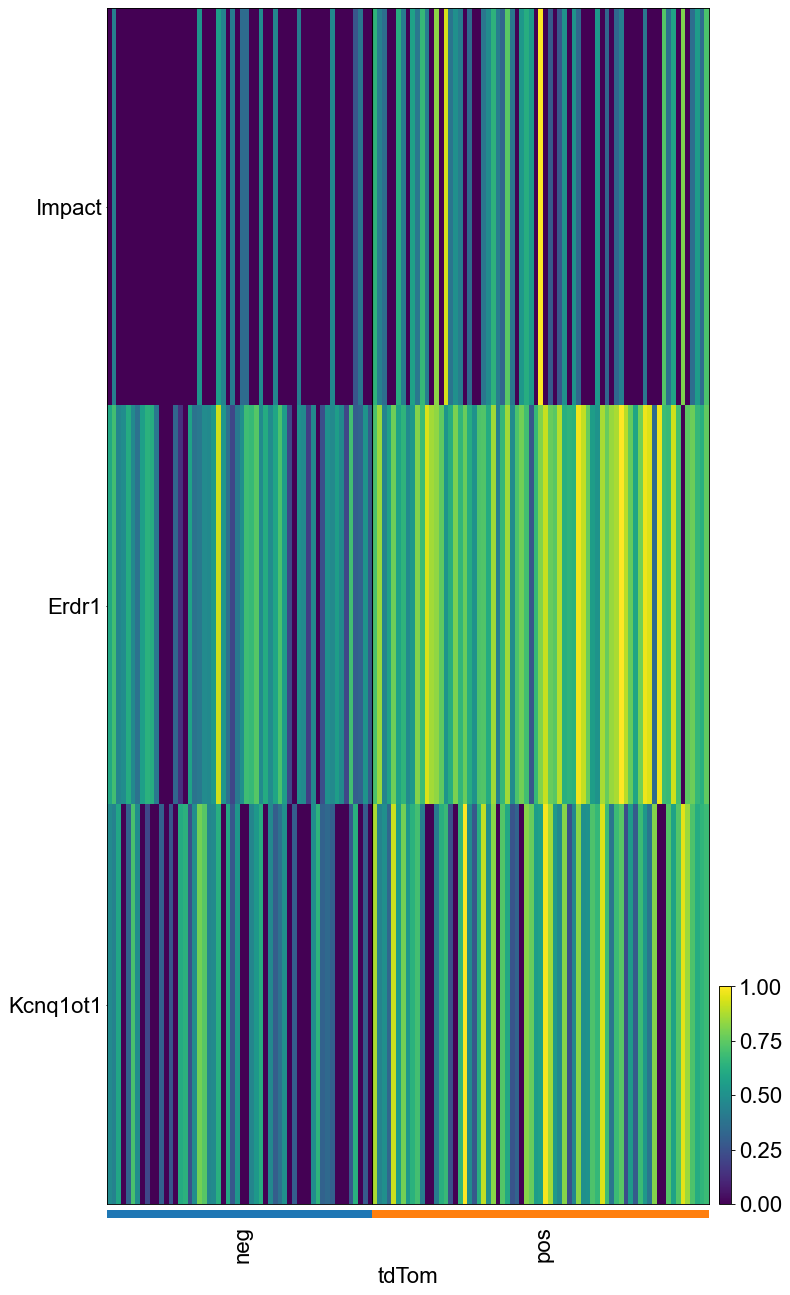

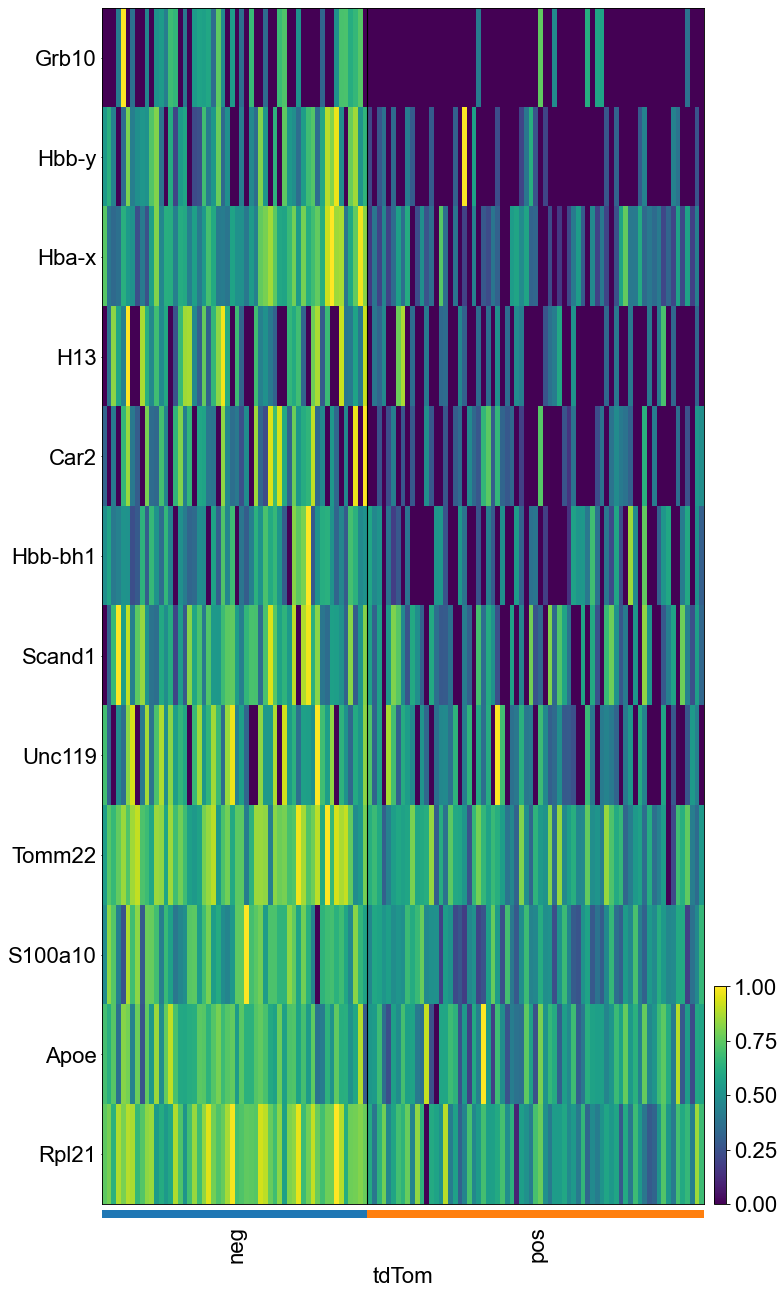

Blood progenitors 2


ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical
... storing 'gut_subclust.mapped' as categorical
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


30
78


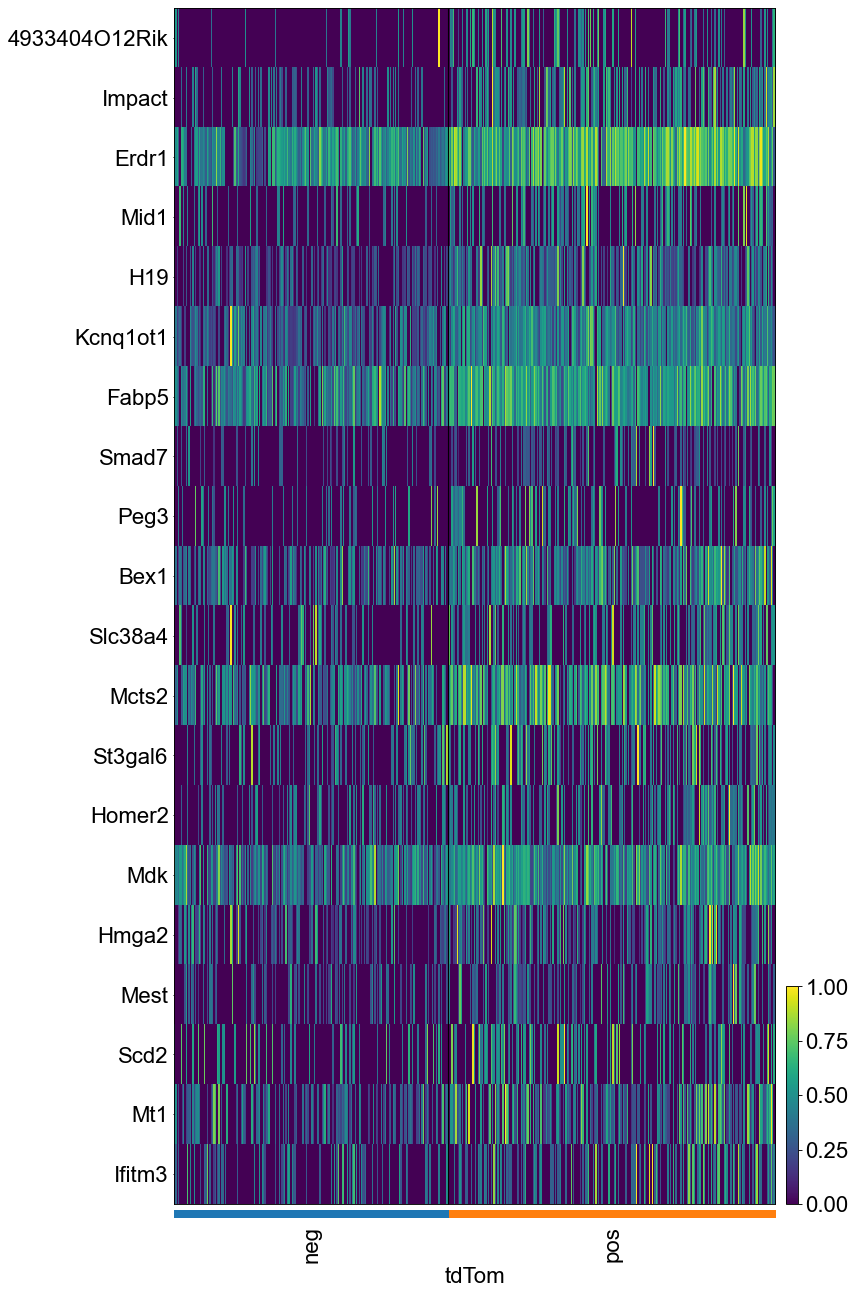

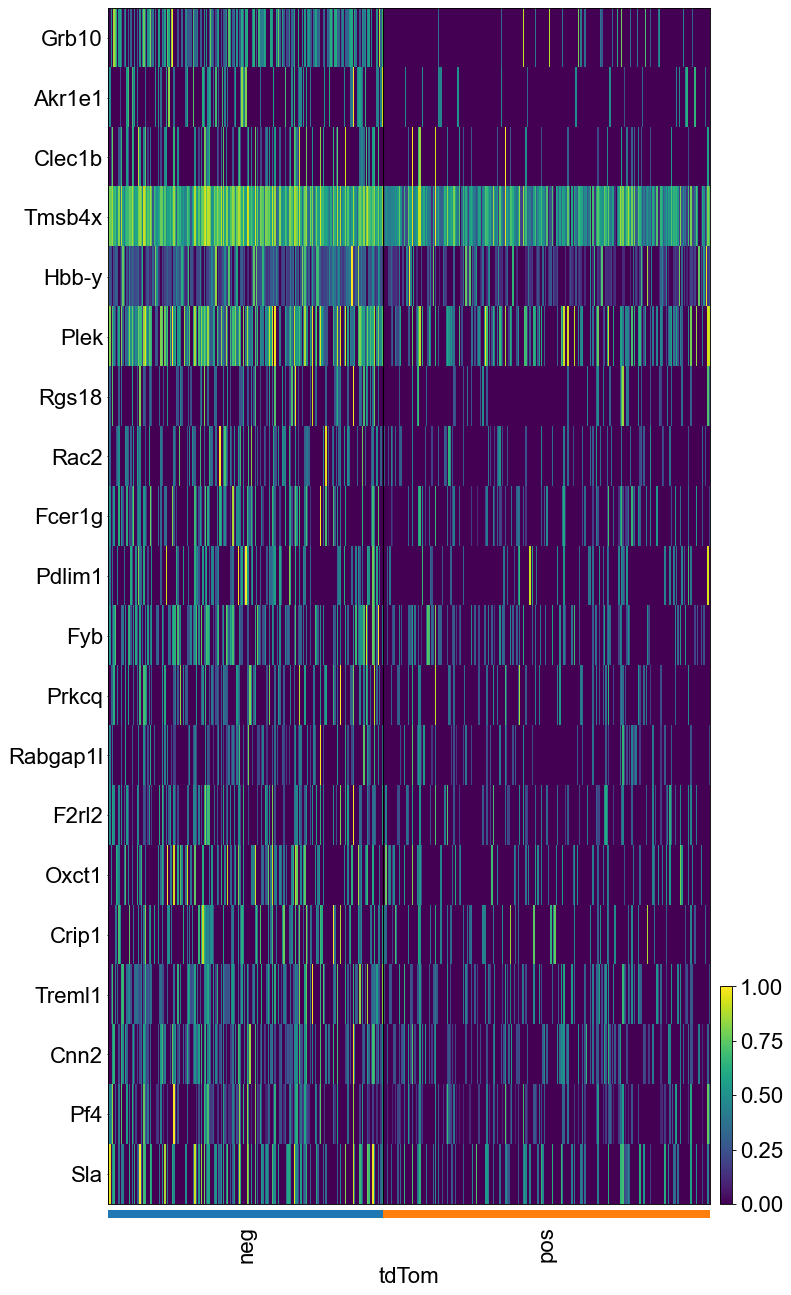

ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical
... storing 'gut_subclust.mapped' as categorical


Cardiomyocytes


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)


58
164


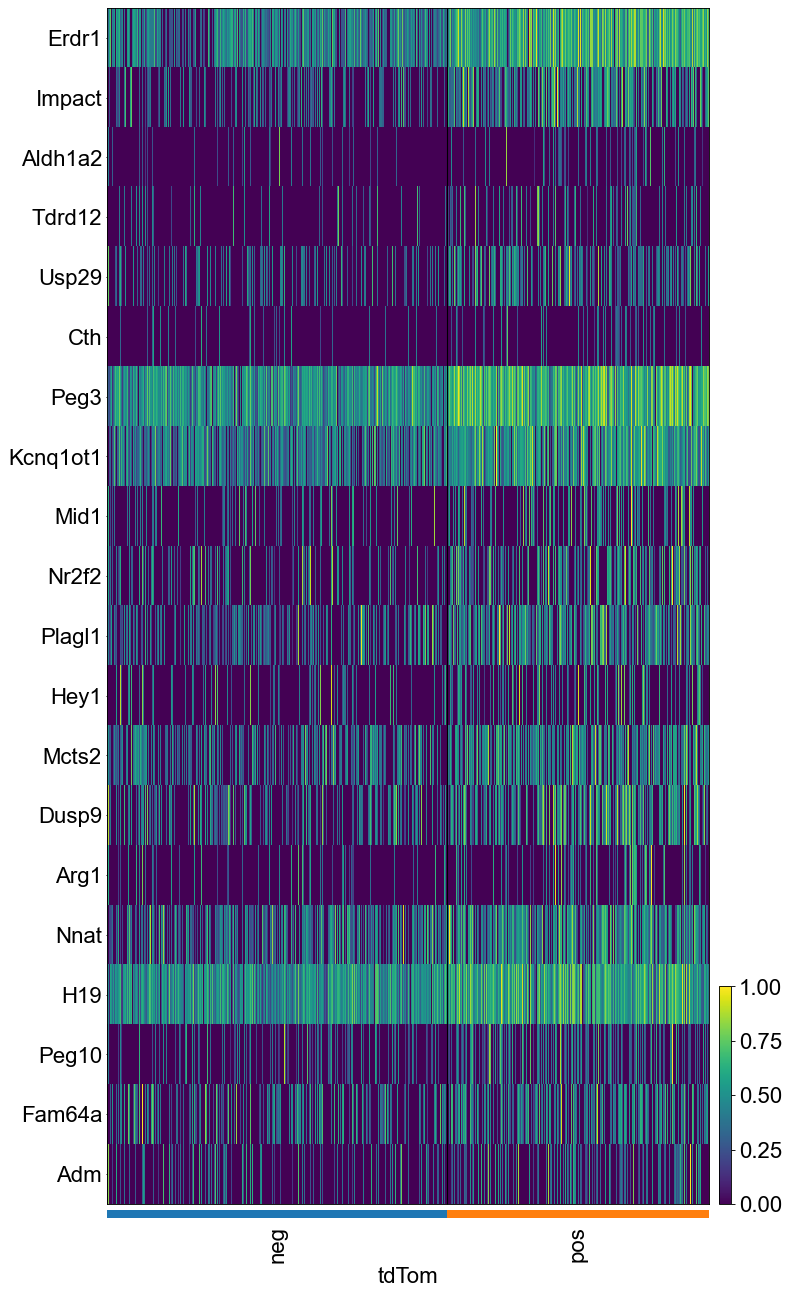

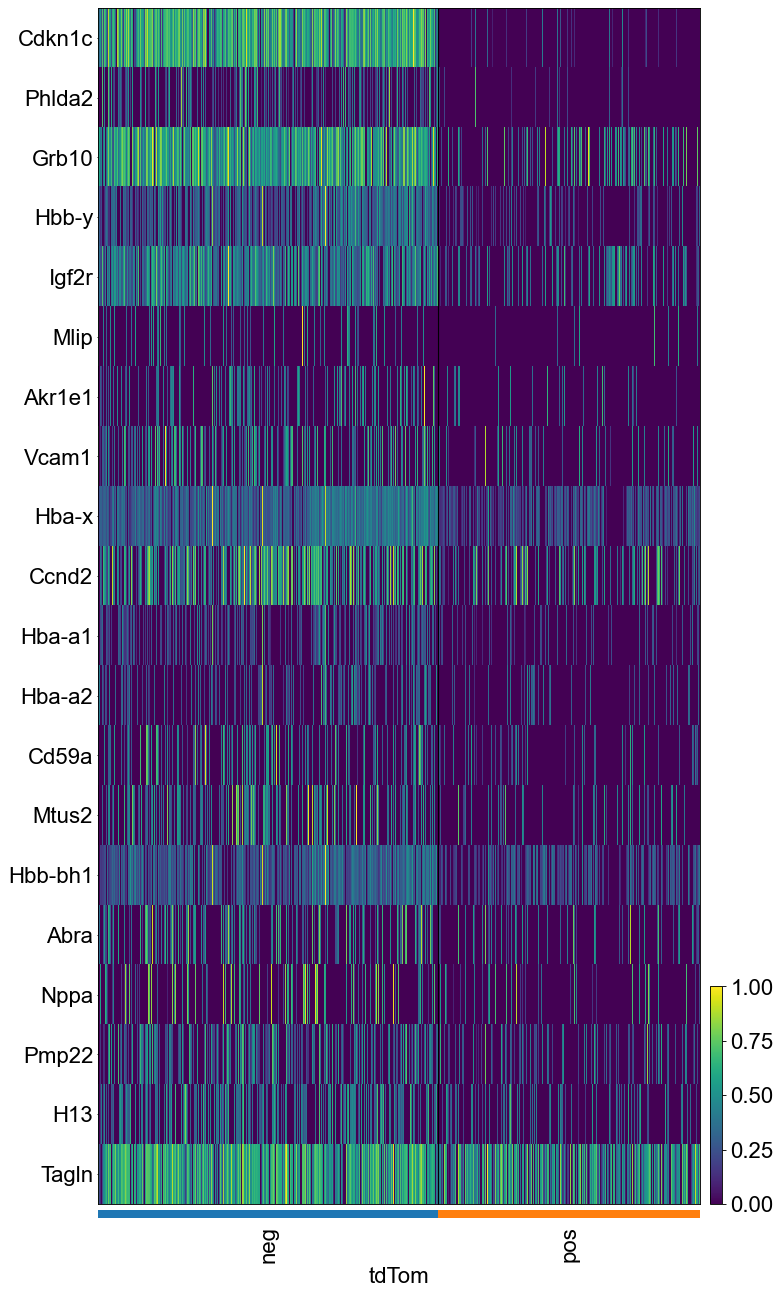

ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical
... storing 'gut_subclust.mapped' as categorical


Caudal Mesoderm


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


3
7


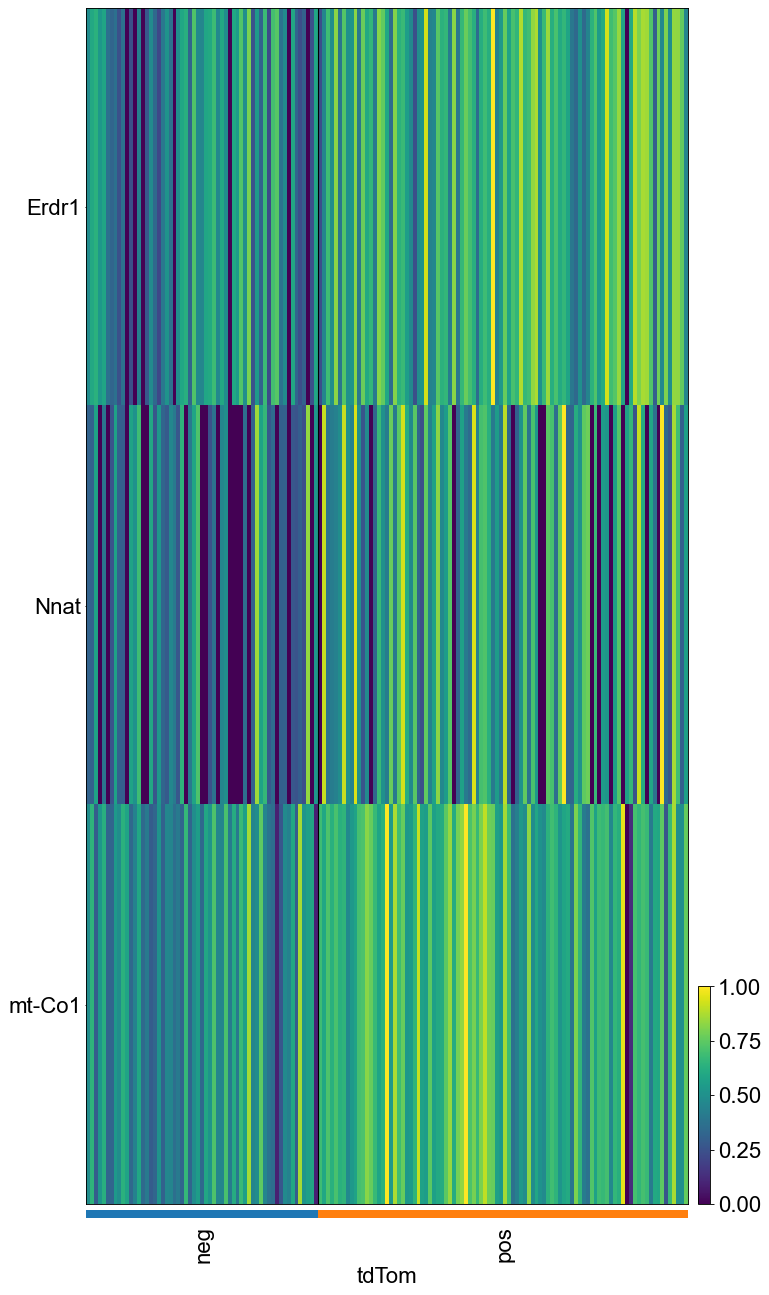

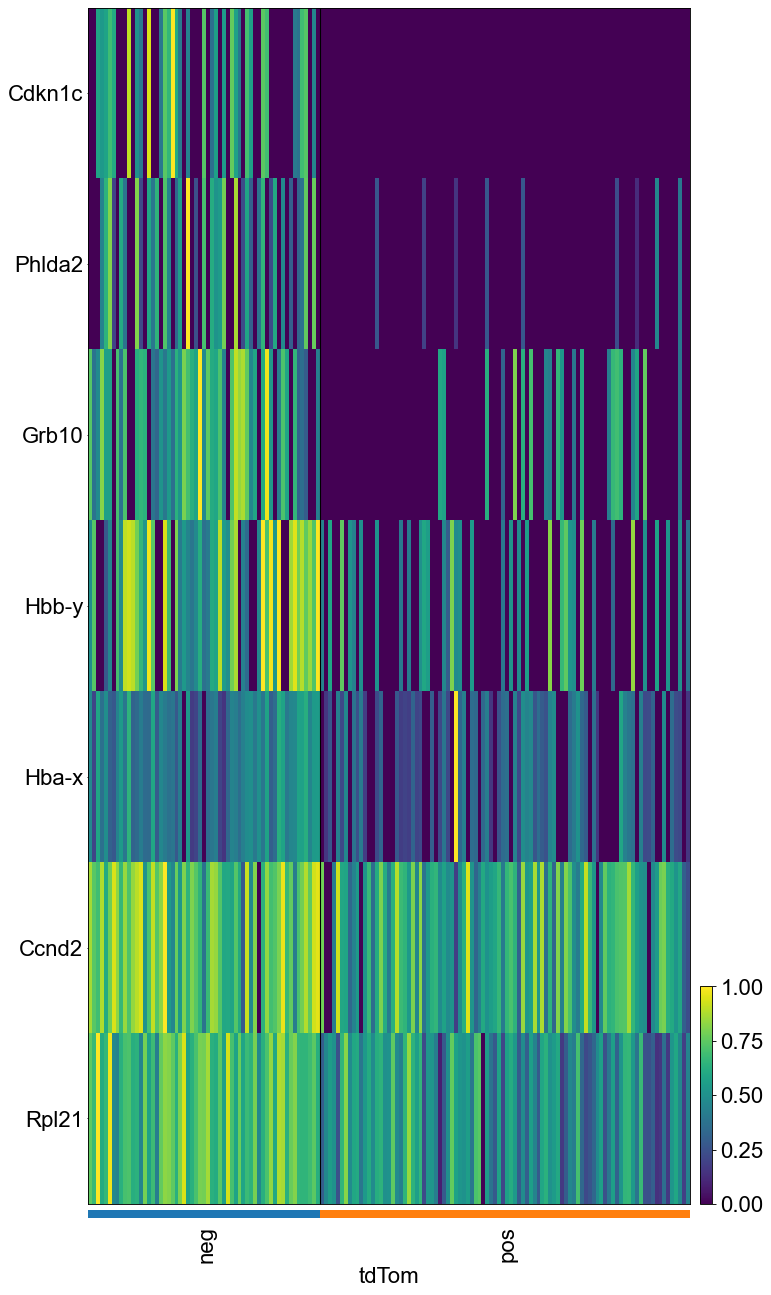

ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical
... storing 'gut_subclust.mapped' as categorical


Def. endoderm


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


55
61


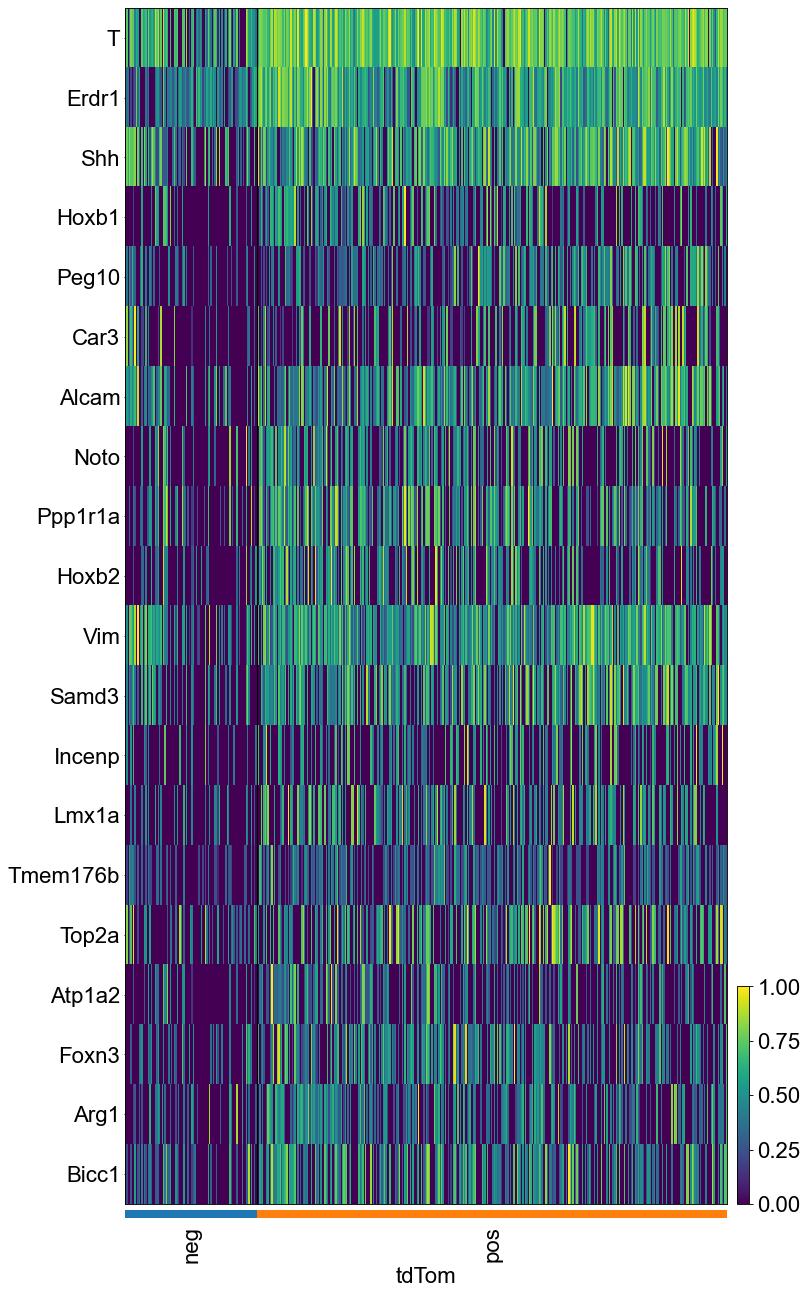

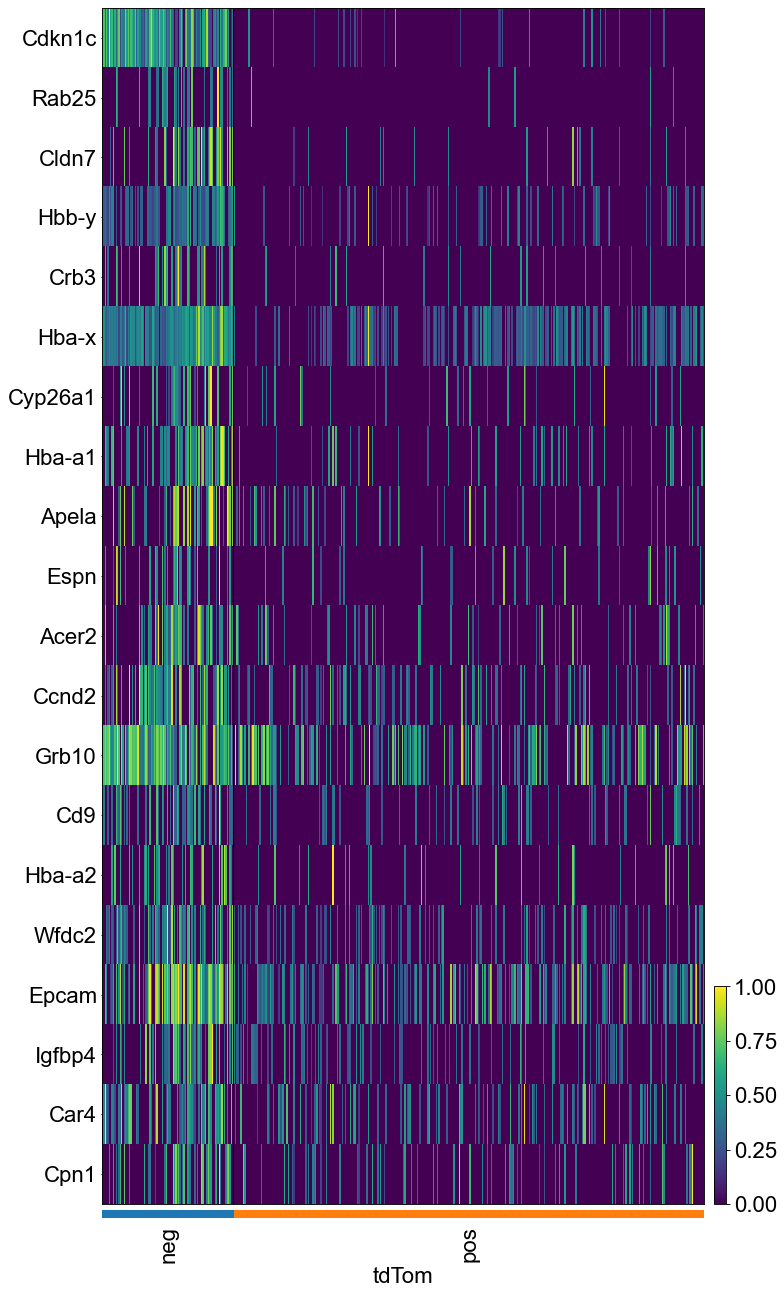

Erythroid1


ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical
... storing 'gut_subclust.mapped' as categorical
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)


27
26


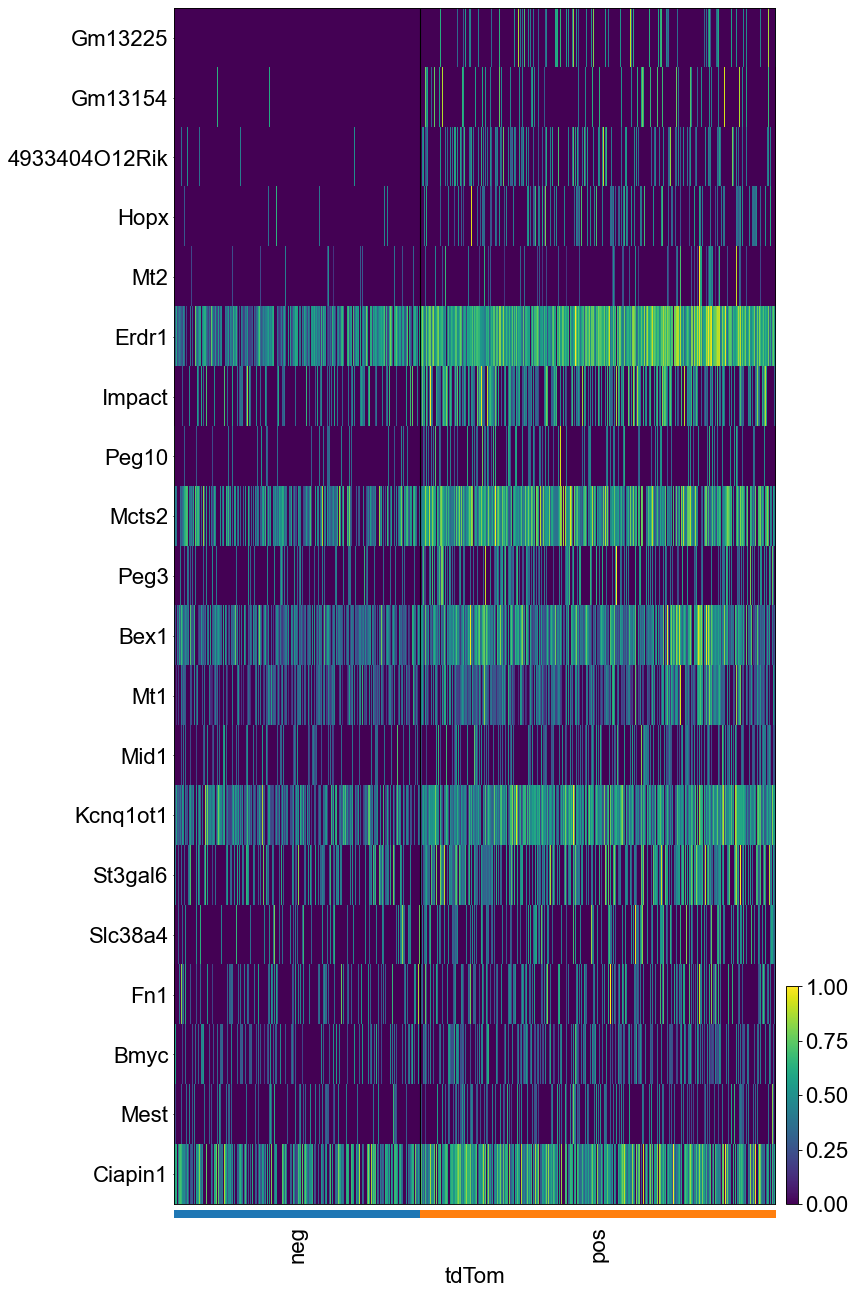

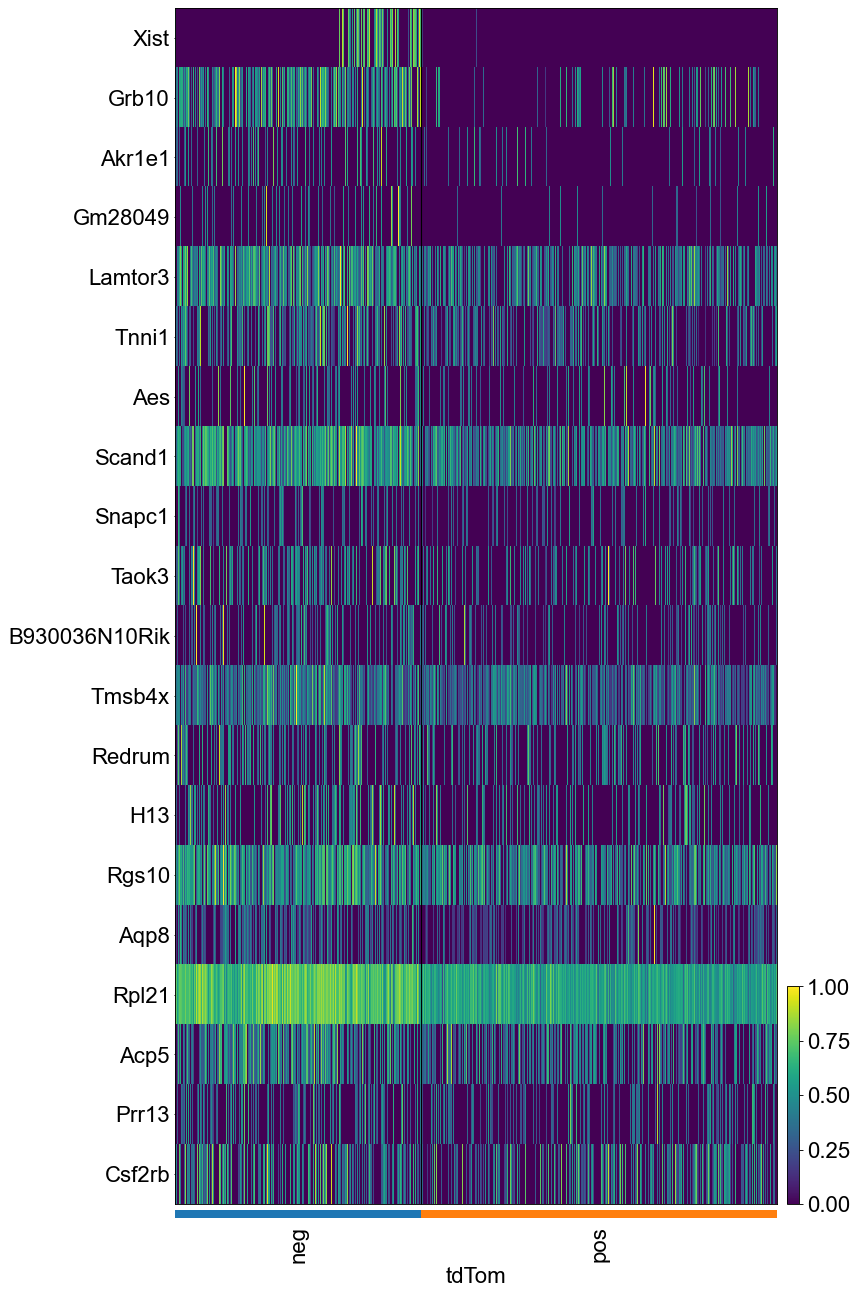

Erythroid2


ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical
... storing 'gut_subclust.mapped' as categorical
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:05)


27
44


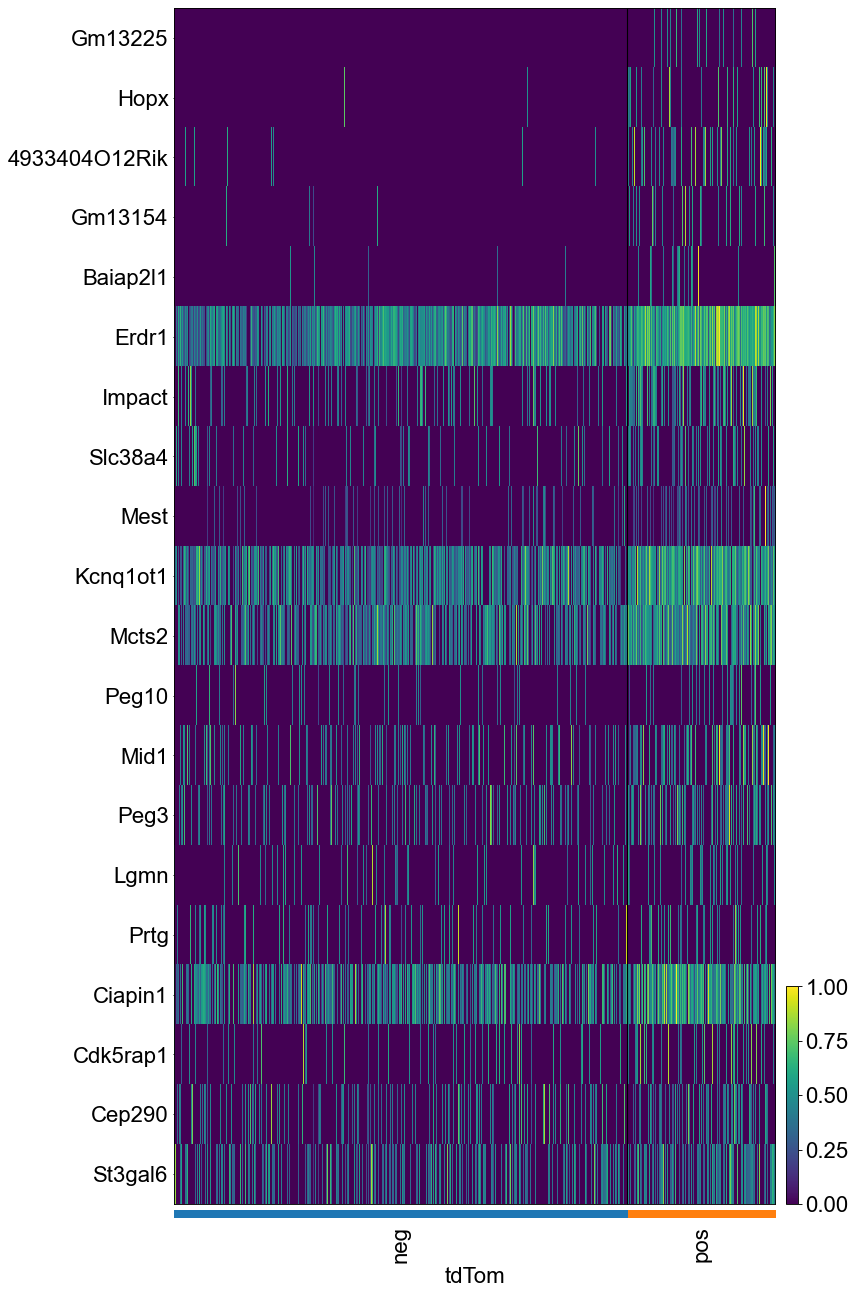

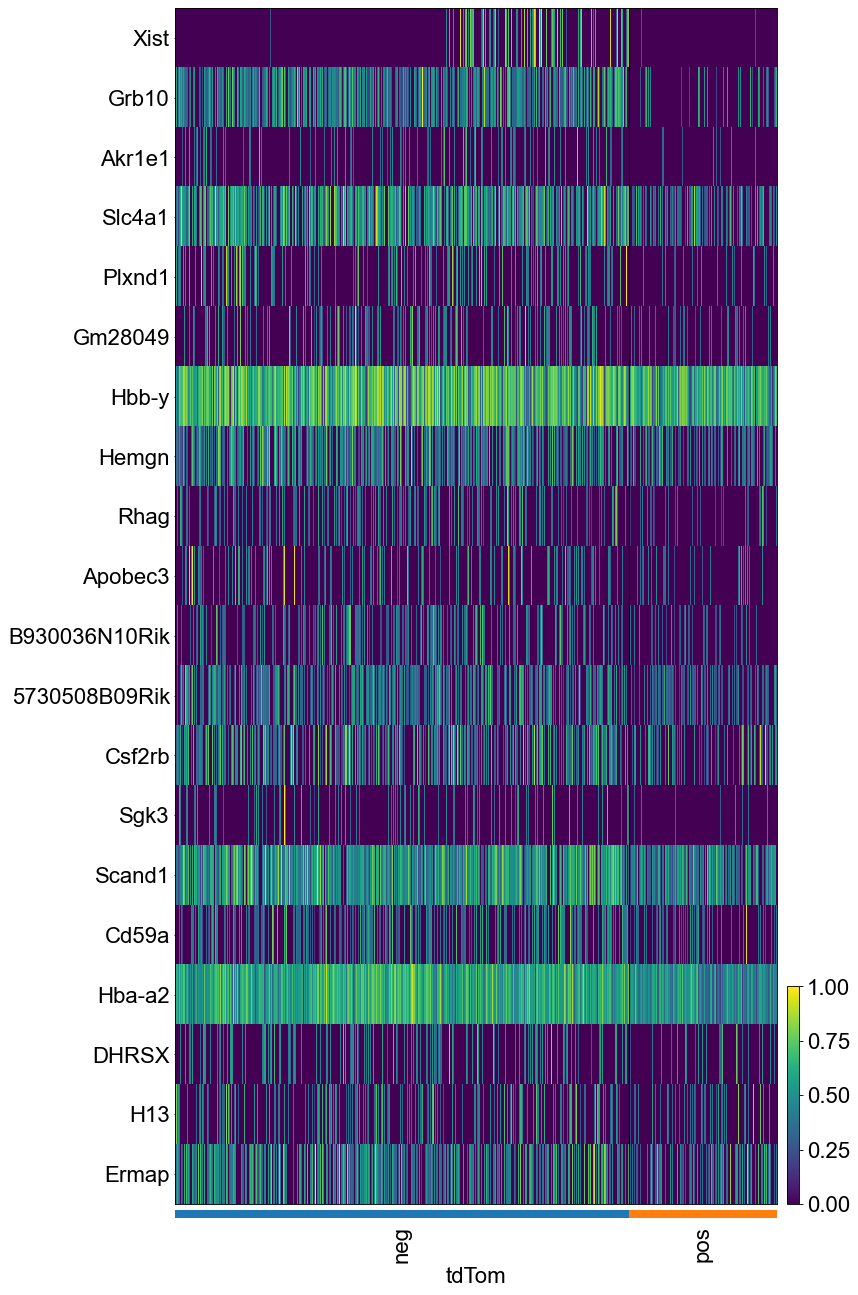

Erythroid3


ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical
... storing 'gut_subclust.mapped' as categorical
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:03)


13
11


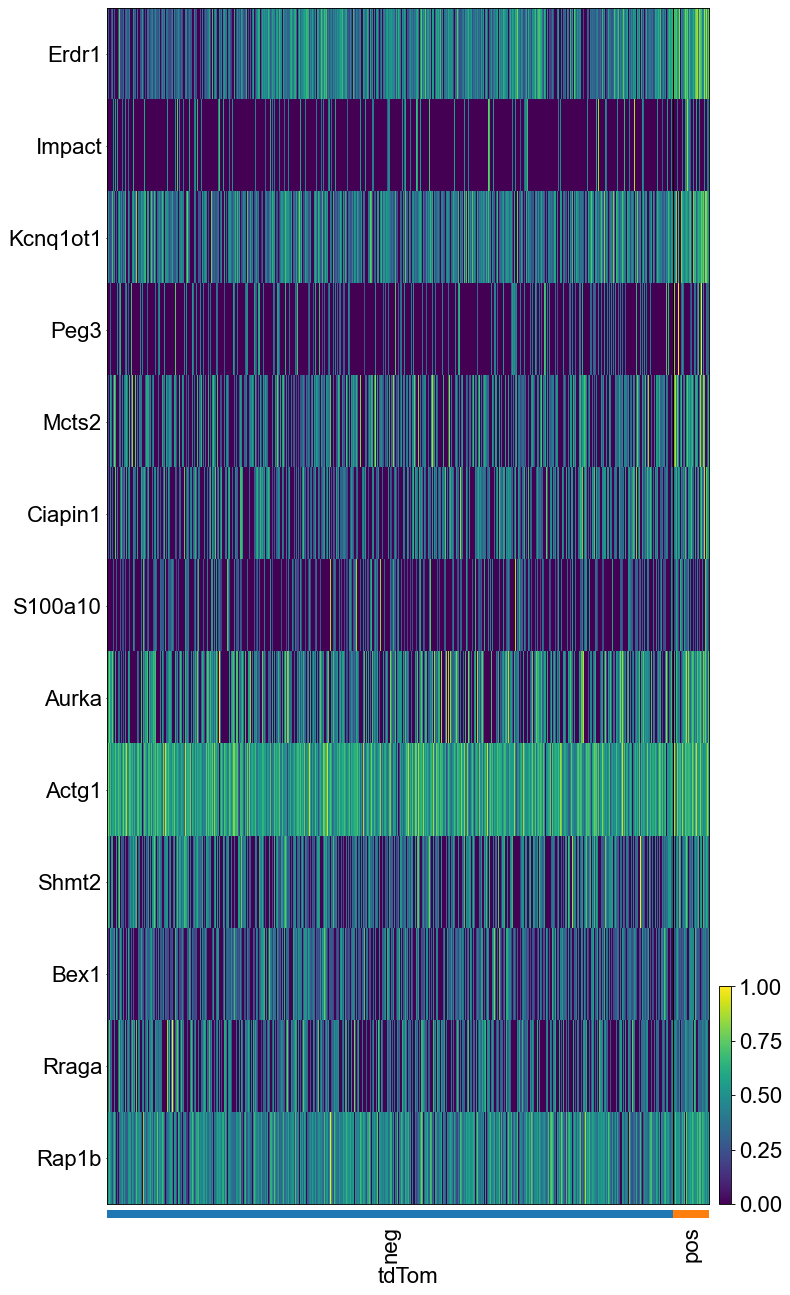

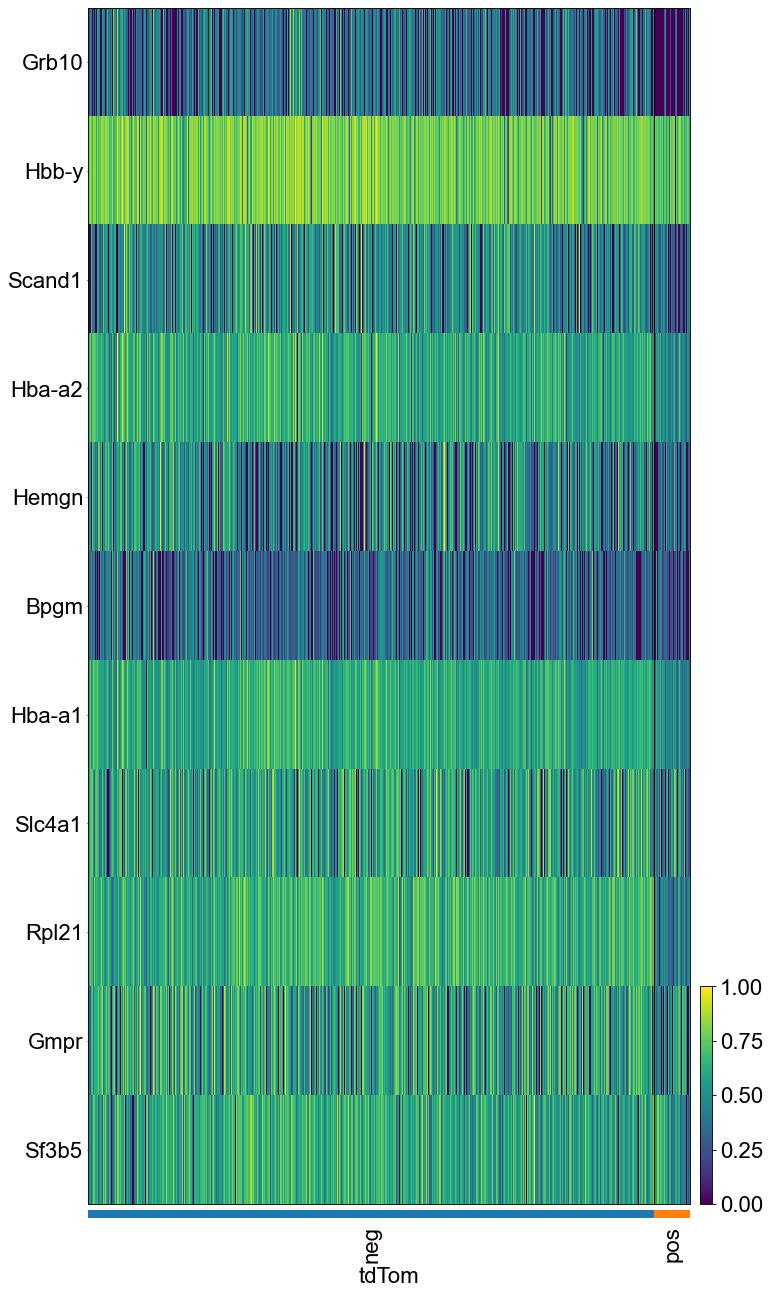

ExE mesoderm


ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical
... storing 'gut_subclust.mapped' as categorical
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:06)


24
39


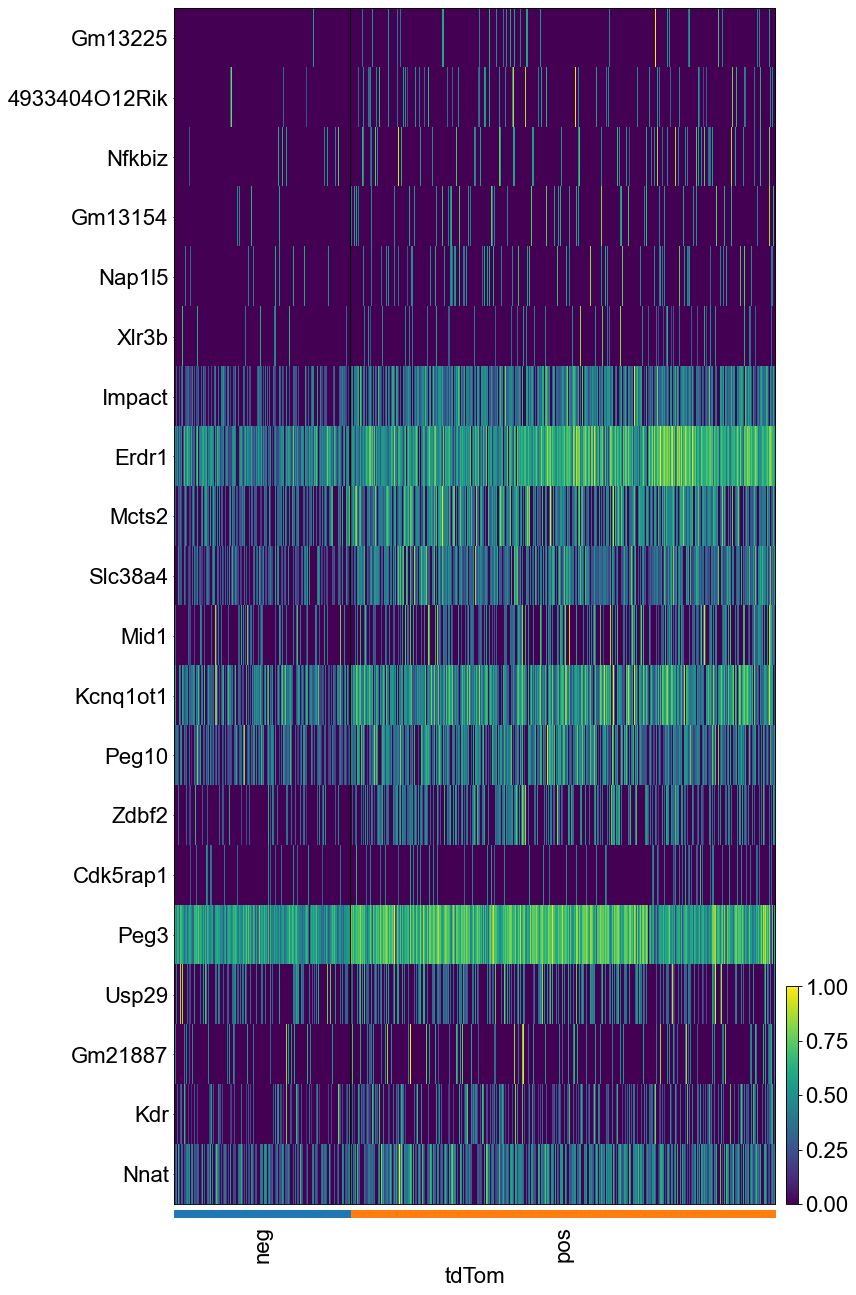

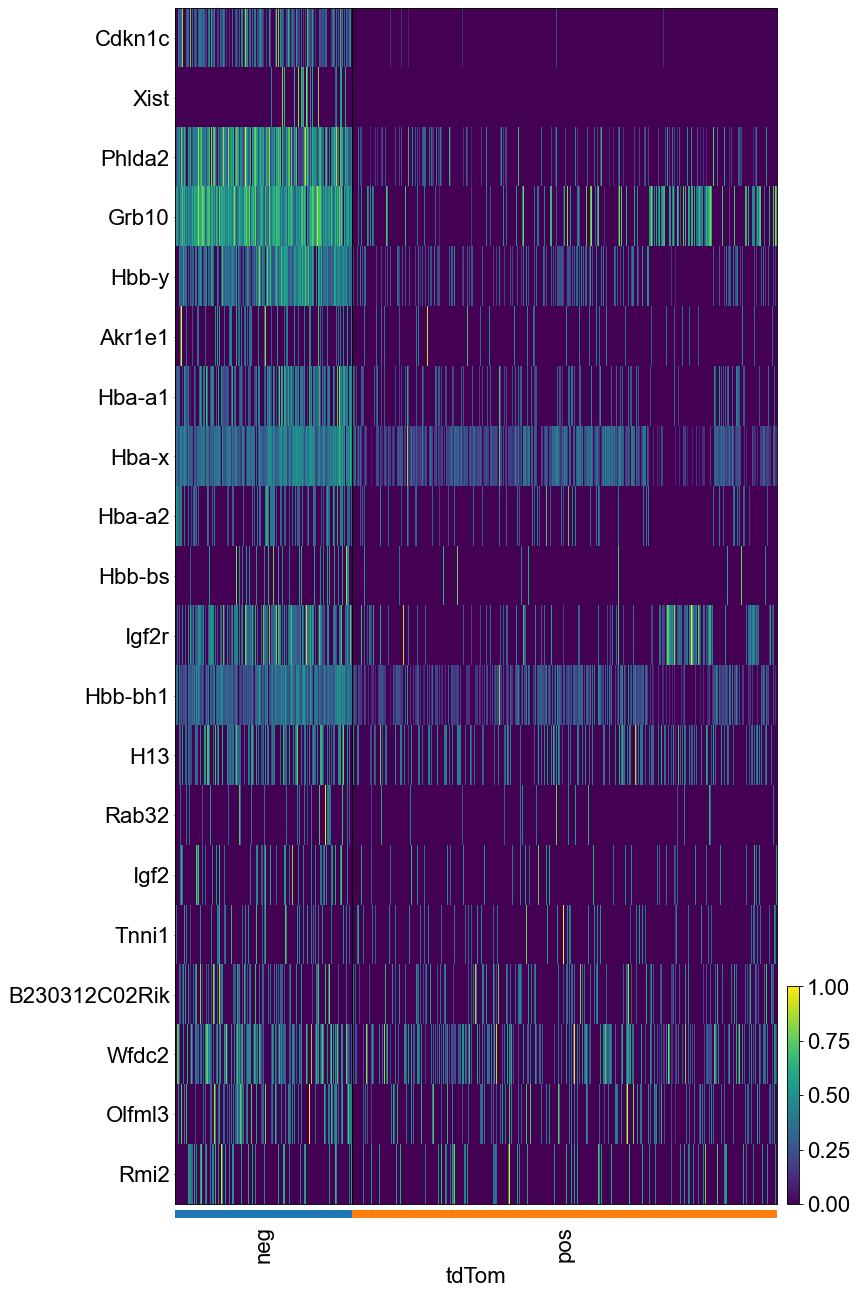

Forebrain/Midbrain/Hindbrain


ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical
... storing 'gut_subclust.mapped' as categorical
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:12)


21
29


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\aamw4\\home\\aamw4\\plots\\heatmaps\\heatmapForebrain\\Midbrain\\Hindbrain_pos.png'

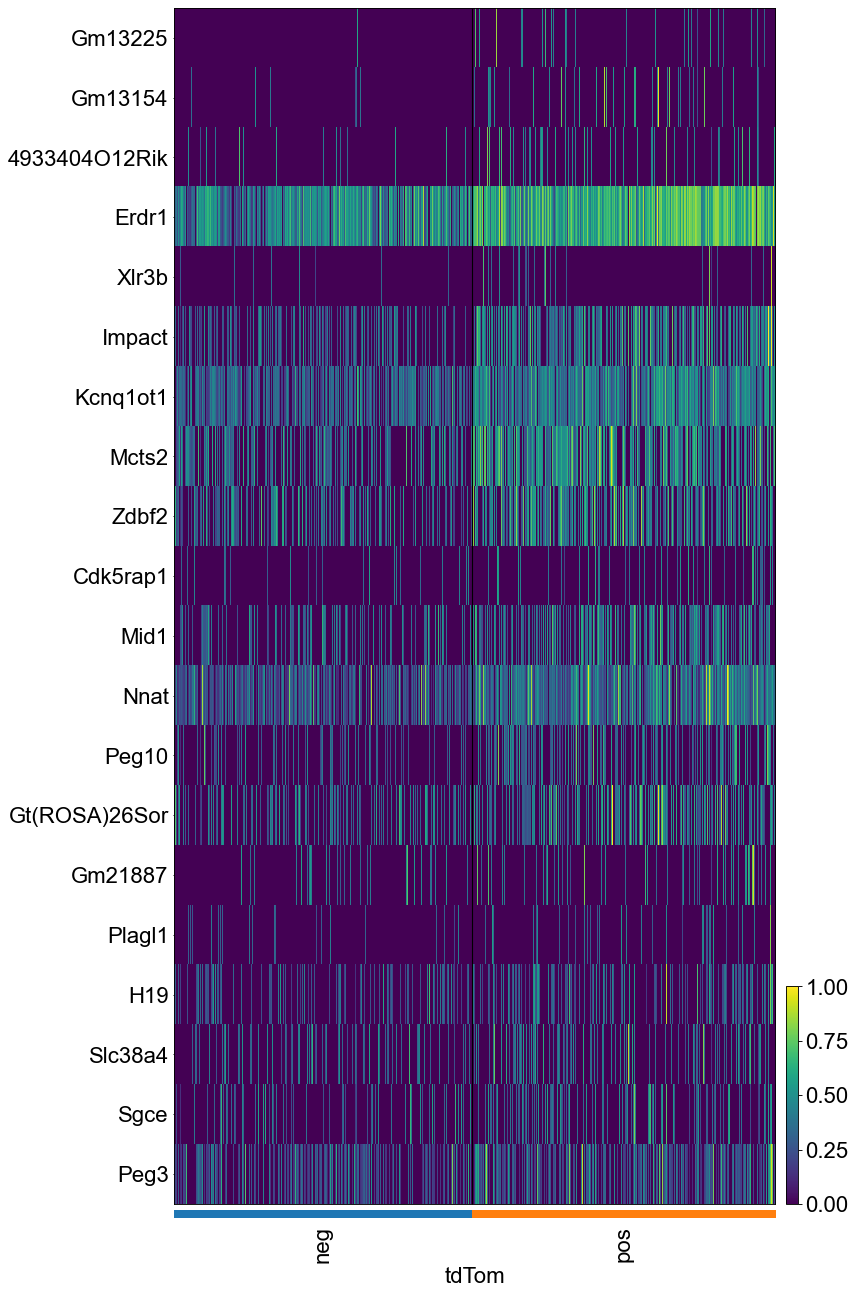

In [127]:
## different one to create DF only with gene names
#wt = pd.read_csv("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/data/wt_tomato_correlations_for_Melania.csv", index_col=1)
#list_names = [name for name in list(wt.index[0:100]) if name in adata.var_names]
sc.settings.figdir = sc.settings.figdir = 'C:/Users/aamw4/home/aamw4/plots/heatmaps/'
sc.set_figure_params(scanpy=True, fontsize=20)
output_dr = 'C:/Users/aamw4/home/aamw4/MAplots/'
number_genes = []
final = pd.DataFrame()

for pop in list(df_good.index):
    print(pop)
    adata_rid = adata[adata.obs['celltype.mapped'] == pop,:].copy()
    sc.tl.rank_genes_groups(adata_rid, groupby='tdTom', groups=['pos','neg'], method='wilcoxon', key = "wilcoxon")
    df1 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['names'])
    df2 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['pvals_adj'])
    df3 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['logfoldchanges'])
    df4 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['scores'])

    
    vec_up = np.where((df3['pos']>=np.log2(1.5)) & (df2['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
    vec_down = np.where((df3['neg']>= np.log2(1.5)) & (df2['neg']<= 0.1) )[0]
    
        
    df_pos = pd.DataFrame(df2.loc[vec_up]['pos'])
    df_pos.index = list(df1.loc[vec_up]['pos'])
    df_pos['lfc'] = list(df3.loc[vec_up]['pos'])
    df_pos = df_pos.sort_values(by='lfc',ascending=False)
    df_pos['scores'] = list(df4.loc[vec_up]['pos'])

 
    df_neg = pd.DataFrame(df2.loc[vec_down]['neg'])
    df_neg.index = list(df1.loc[vec_down]['neg'])
    df_neg['lfc'] = list(df3.loc[vec_down]['neg'])
    df_neg = df_neg.sort_values(by='lfc',ascending=False)
    df_neg['scores'] = list(df4.loc[vec_down]['pos'])

 
    lista_n = df_neg.index
    lista_p = df_pos.index
 
    print(len(lista_p))
    print(len(lista_n))
    
    number_pos = len(lista_p)
    number_neg = len(lista_n)
    
    number_genes.append(number_pos)
    number_genes.append(number_neg)
    
    #make a list with lengths of all lists, sort and take maximum
    
    list_pos = lista_p.tolist() #format to list to add to dataframe
    list_neg = lista_n.tolist()
    
    #create DataFrame final with only gene names according to celltype and tdTom 
    
    df_posi = pd.DataFrame({'pos': list_pos})
    df_nega = pd.DataFrame({'neg': list_neg})
    
    
    columns = create_tuple_for_for_columns(df_posi, pop)
    df_posi.columns = pd.MultiIndex.from_tuples(columns)
    
    index = pd.MultiIndex.from_tuples(df_posi, names=['celltype', 'tdTom'])
    df_posi.columns = index
    
    columns = create_tuple_for_for_columns(df_nega, pop)
    df_nega.columns = pd.MultiIndex.from_tuples(columns)
    
    index = pd.MultiIndex.from_tuples(df_nega, names=['celltype', 'tdTom'])
    df_nega.columns = index 

    df_pn = pd.concat([df_posi, df_nega], axis=1)
    index = pd.MultiIndex.from_tuples(df_pn, names=['celltype', 'tdTom'])
    df_pn.columns = index
    
    final = pd.concat([final, df_pn], axis=1)
    
    #heatmaps
    adata_rid.var_names_make_unique()
    
    if len(df_posi) > 20:
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,0].head(20), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_pos.png' )
    else : 
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,0].head(len(df_posi)), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_pos.png' )
            
    if len(df_nega) > 20:
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,1].head(20), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_neg.png' )
    else:
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,1].head(len(df_nega)), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_neg.png' )
    plt.rcParams.update({'font.size': 24})
    
    #ranks for GSEA
    ll = list(df1.pos)
    lista = [x.upper() for x in ll]
    df = pd.DataFrame(lista)
    df['score'] = df4.iloc[:,0]
    df.to_csv("C:/Users/aamw4/home/aamw4/plots/MAplots" + '{}'.format(pop)+'KOpos_vs_KOneg.rnk',sep = '\t', header=None, index=None)
    
    
print('finished ranking genes')
number_genes.sort(reverse=True)
number_genes[0] #prints highest number of selected genes for any celltype population to adapt range accordingly of df-Dea in initialisation

In [33]:
final.to_csv(out_folder + 'chim_DEGs_final')

In [301]:
final = pd.read_csv('C:/Users/aamw4/home/aamw4/number_DEGs.csv')
df_chim = pd.read_csv('C:/Users/aamw4/home/aamw4/chim_DEGs_df_dea.csv')
df_wt = pd.read_csv('C:/Users/aamw4/home/aamw4/wt_DEGs_df_dea.csv')

In [302]:
final = final.iloc[1::3,]

In [303]:
final['Unnamed: 2'].iloc[1::2,] = 'neg'

In [311]:
final['Unnamed: 2'].iloc[0::2,] = 'pos'

C:\Users\aamw4\Anaconda3\lib\site-packages\pandas\core\indexing.py:670: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iloc._setitem_with_indexer(indexer, value)


In [309]:
final['Celltype'] = final['Celltype'].str[:-4]

In [320]:
final = final.rename(columns={"Unnamed: 2": "tdTom"})

In [321]:
final

,Celltype,Counts,tdTom,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
1,Allantois,38,pos,NaN,NaN,NaN,NaN,NaN
4,Allantois,93,neg,NaN,NaN,NaN,NaN,NaN
7,Blood progenitors 1,3,pos,NaN,NaN,NaN,NaN,NaN
10,Blood progenitors 1,11,neg,NaN,NaN,NaN,NaN,NaN
13,Blood progenitors 2,29,pos,NaN,NaN,NaN,NaN,NaN
16,Blood progenitors 2,71,neg,NaN,NaN,NaN,NaN,NaN
19,Cardiomyocytes,58,pos,NaN,NaN,NaN,NaN,NaN
22,Cardiomyocytes,162,neg,NaN,NaN,NaN,NaN,NaN
25,Caudal Mesoderm,3,pos,NaN,NaN,NaN,NaN,NaN
28,Caudal Mesoderm,6,neg,NaN,NaN,NaN,NaN,NaN


In [282]:
# import seaborn
import seaborn as sns
%matplotlib inline

Text(0.5, 1.0, 'Number of DEGs in Mixl1 chimera')

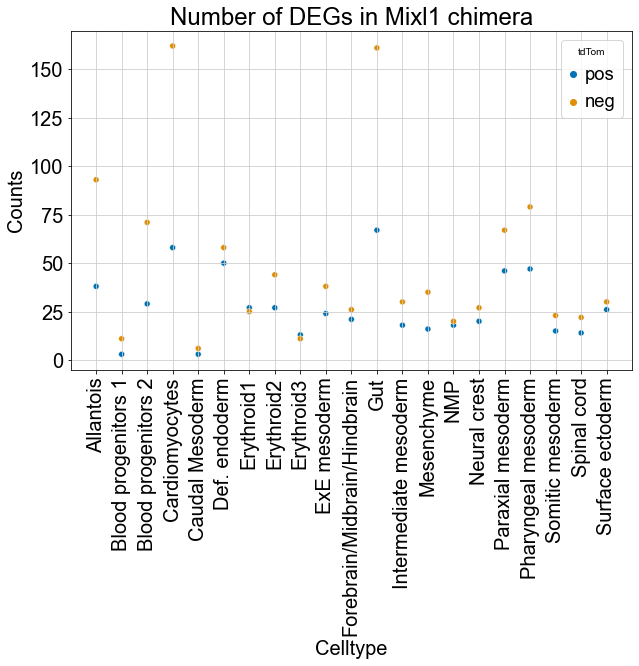

In [335]:
plt.figure(figsize=(10,6))
ax = sns.scatterplot(y='Counts', x='Celltype',  #0 is number of DEGs/celltype
                 data=final, 
                 palette="colorblind",
                 hue='tdTom', legend='full', )
#ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
plt.xticks(rotation=90)
plt.title("Number of DEGs in Mixl1 chimera", size=24)

# DEG for WT injected cells

In [34]:
adata_wt.obs['tomato'] = adata_wt.obs['tomato'].replace([0, 1],['neg','pos'])

In [35]:
df = pd.crosstab(adata_wt.obs['celltype.mapped'], adata_wt.obs['tomato'])
#df = df.rename(columns={0: "neg", 1: "pos"})
vec = np.array((df.neg>=50) & (df.pos>=50))
print(vec)
df_good_wt = df.loc[vec] #df.iloc[vec] does not work for one reason I don't understand, but df.loc[voc] takes away index
print(df_good_wt)
print(df_good_wt.dtypes)


[False False  True  True False  True  True False False  True False  True
 False False  True False False  True  True  True  True  True  True  True
  True  True False False False  True False  True  True  True  True  True
 False  True False]
tomato                          neg   pos
celltype.mapped                          
Blood progenitors 1              96    89
Blood progenitors 2             212   236
Caudal Mesoderm                  95   174
Caudal epiblast                 248   428
Doublet                         282   574
Epiblast                        222   225
Erythroid3                      164   253
ExE mesoderm                     85   263
Forebrain/Midbrain/Hindbrain    143   256
Gut                             194   244
Haematoendothelial progenitors  201   296
Intermediate mesoderm           166   335
Mesenchyme                      456  1025
Mixed mesoderm                   75   103
NMP                              66   124
Nascent mesoderm                137   166
Parax

In [36]:
list_common = [pop for pop in df_good.index if pop in df_good_wt.index]

In [37]:
list_common

['Blood progenitors 1',
 'Blood progenitors 2',
 'Caudal Mesoderm',
 'Erythroid3',
 'ExE mesoderm',
 'Forebrain/Midbrain/Hindbrain',
 'Gut',
 'Intermediate mesoderm',
 'Mesenchyme',
 'NMP',
 'Paraxial mesoderm',
 'Pharyngeal mesoderm',
 'Somitic mesoderm',
 'Spinal cord',
 'Surface ectoderm']

In [38]:
def create_tuple_for_for_columns(df_a, multi_level_col):
    """
    Create a columns tuple that can be pandas MultiIndex to create multi level column

    :param df_a: pandas dataframe containing the columns that must form the first level of the multi index
    :param multi_level_col: name of second level column
    :return: tuple containing (second_level_col, firs_level_cols)
    """
    temp_columns = []
    for item in df_a.columns:
        temp_columns.append((multi_level_col, item))
    return temp_columns

In [39]:
sc.settings.figdir = '/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plots/heatmaps/'
ran = range(0,519)
df_dea = pd.DataFrame().reindex(ran) #initialization of df_dea #ValueError: Cannot set a frame with no defined index and a value that cannot be converted to a Series
df_dea.dropna(inplace=True)
number_genes = []


for pop in list(list_common):
    print(pop)
    adata_rid = adata_wt[adata_wt.obs['celltype.mapped'] == pop,:].copy()
    sc.tl.rank_genes_groups(adata_rid, groupby='tomato', groups=['pos','neg'], method='wilcoxon', key = "wilcoxon")
    df5 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['names'])
    df6 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['pvals_adj'])
    df7 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['logfoldchanges'])

    
    vec_up = np.where((df7['pos']>=np.log2(1.5)) & (df6['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
    vec_down = np.where((df7['neg']>= np.log2(1.5)) & (df6['neg']<= 0.1) )[0]
    
        
    df_pos = pd.DataFrame(df6.loc[vec_up]['pos'])
    df_pos.index = list(df5.loc[vec_up]['pos'])
    df_pos['lfc'] = list(df7.loc[vec_up]['pos'])
    df_pos = df_pos.sort_values(by='lfc',ascending=False)

 
    df_neg = pd.DataFrame(df6.loc[vec_down]['neg'])
    df_neg.index = list(df5.loc[vec_down]['neg'])
    df_neg['lfc'] = list(df7.loc[vec_down]['neg'])
    df_neg = df_neg.sort_values(by='lfc',ascending=False)

 
    lista_n = df_neg.index
    lista_p = df_pos.index
 
    print(len(lista_p))
    print(len(lista_n))
    
    number_pos = len(lista_p)
    number_neg = len(lista_n)
    
    number_genes.append(number_pos)
    number_genes.append(number_neg)
    
    #make a list with lengths of all lists, sort and take maximum
    
    list_pos = lista_p.tolist() #format to list to add to dataframe
    list_neg = lista_n.tolist()
    
    ##create df_dea with gene names, pvaladj and lfc
           
    df_dea[pop + '_pos_g'] = pd.Series(list_pos) #to avoid errors from different lengths, convert to Series
    df_dea[pop + '_pos_pvaladj'] = pd.Series(list(df_pos['pos']))
    df_dea[pop + '_pos_lfc'] = pd.Series(list(df_pos['lfc']))
    
    
    df_dea[pop + '_neg_g'] = pd.Series(list_neg)
    df_dea[pop + '_neg_pvaladj'] = pd.Series(list(df_neg['neg']))
    df_dea[pop + '_neg_lfc'] = pd.Series(list(df_neg['lfc']))
    
        
print('finished ranking genes')
number_genes.sort(reverse=True)
number_genes[0] #prints highest number of selected genes for any celltype population to adapt range accordingly of df-Dea in initialisation

Blood progenitors 1
ranking genes


... storing 'celltype.mapped' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tomato' as categorical
... storing 'gene_symbols' as categorical


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
7
12
Blood progenitors 2
ranking genes


... storing 'celltype.mapped' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tomato' as categorical
... storing 'gene_symbols' as categorical


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
19
32
Caudal Mesoderm
ranking genes


...

... storing 'celltype.mapped' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tomato' as categorical
... storing 'gene_symbols' as categorical


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
261
74
Surface ectoderm
ranking genes


... storing 'celltype.mapped' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'tomato' as categorical
... storing 'gene_symbols' as categorical


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)
22
29
finished ranking genes


519

In [40]:
df_dea.to_csv(out_folder + 'wt_DEGs_df_dea.csv')

# MA plot showing DEGs WT injection relative to chimera

In [75]:
#chim
df = pd.crosstab(adata.obs['celltype.mapped'], adata.obs['tdTom'])
vec = np.array((df.neg>=50) & (df.pos>=50))
print(vec)
df_good = df.loc[vec] #df.iloc[vec] does not work for one reason I don't understand, but df.loc[voc] takes away index
print(df_good)
print(df_good.dtypes)

[ True False  True  True  True  True False False  True False  True  True
  True False False  True  True  True False  True  True False  True  True
 False False  True False  True False  True  True  True False]
tdTom                          neg   pos
celltype.mapped                         
Allantois                      738  2143
Blood progenitors 1             56    71
Blood progenitors 2            210   250
Cardiomyocytes                 691   534
Caudal Mesoderm                 59    94
Def. endoderm                   97   347
Erythroid1                     467   674
Erythroid2                    1881   614
Erythroid3                    1427    91
ExE mesoderm                   874  2103
Forebrain/Midbrain/Hindbrain  2641  2696
Gut                            929   173
Intermediate mesoderm          505  1120
Mesenchyme                     188   452
NMP                            960  1089
Neural crest                   832   575
Paraxial mesoderm             1351  1255
Pharyngeal me

In [76]:
#WT
df = pd.crosstab(adata_wt.obs['celltype.mapped'], adata_wt.obs['tdTom'])
#df = df.rename(columns={0: "neg", 1: "pos"})
vec = np.array((df.neg>=50) & (df.pos>=50))
print(vec)
df_good_wt = df.loc[vec] #df.iloc[vec] does not work for one reason I don't understand, but df.loc[voc] takes away index
print(df_good_wt)
print(df_good_wt.dtypes)


[False False  True  True False  True False False False False False  True
  True  True False False  True  True  True  True  True  True False  True
  True False False False  True False  True False  True  True  True  True
 False]
tdTom                           neg  pos
celltype.mapped                         
Blood progenitors 1              95   87
Blood progenitors 2             251  266
Caudal Mesoderm                  87  169
Erythroid1                       53   92
Erythroid2                       53  103
Erythroid3                      146  190
ExE mesoderm                    198  489
Forebrain/Midbrain/Hindbrain    430  691
Gut                             196  249
Haematoendothelial progenitors  178  290
Intermediate mesoderm           204  396
Mesenchyme                      361  858
NMP                             265  515
Nascent mesoderm                117  149
Paraxial mesoderm               273  580
Pharyngeal mesoderm             150  397
Rostral neurectoderm            486

In [77]:
list_common = [pop for pop in df_good.index if pop not in df_good_wt.index]

list_common

['Blood progenitors 1',
 'Blood progenitors 2',
 'Caudal Mesoderm',
 'Erythroid1',
 'Erythroid2',
 'Erythroid3',
 'ExE mesoderm',
 'Forebrain/Midbrain/Hindbrain',
 'Gut',
 'Intermediate mesoderm',
 'Mesenchyme',
 'NMP',
 'Paraxial mesoderm',
 'Pharyngeal mesoderm',
 'Somitic mesoderm',
 'Spinal cord',
 'Surface ectoderm']

In [216]:
final = pd.read_csv('C:/Users/aamw4/home/aamw4/chim_DEGs_final', header = [0,1], sep = ",")
df_chim = pd.read_csv('C:/Users/aamw4/home/aamw4/chim_DEGs_df_dea.csv')
df_wt = pd.read_csv('C:/Users/aamw4/home/aamw4/wt_DEGs_df_dea.csv')


In [86]:
unique_genes = pd.DataFrame()
for pop in list_common:    
    dfn = [gene for gene in list(df_chim[pop + '_neg_g']) if gene not in list(df_wt[pop + '_neg_g'])]
    dfp = [gene for gene in list(df_chim[pop + '_pos_g']) if gene not in list(df_wt[pop + '_pos_g'])]
    unique_genes[pop + '_neg_g'] = pd.Series(dfn)
    unique_genes[pop + '_pos_g'] = pd.Series(dfp)
unique_genes

<ipython-input-86-2f9374d2c438>:6: DeprecationWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  unique_genes[pop + '_pos_g'] = pd.Series(dfp)


,Blood progenitors 1_neg_g,Blood progenitors 1_pos_g,Blood progenitors 2_neg_g,Blood progenitors 2_pos_g,Caudal Mesoderm_neg_g,Caudal Mesoderm_pos_g,Erythroid1_neg_g,Erythroid1_pos_g,Erythroid2_neg_g,Erythroid2_pos_g,...,Paraxial mesoderm_neg_g,Paraxial mesoderm_pos_g,Pharyngeal mesoderm_neg_g,Pharyngeal mesoderm_pos_g,Somitic mesoderm_neg_g,Somitic mesoderm_pos_g,Spinal cord_neg_g,Spinal cord_pos_g,Surface ectoderm_neg_g,Surface ectoderm_pos_g
0,Grb10,NaN,Clec1b,H19,Grb10,mt-Co1,Grb10,Hopx,Grb10,Hopx,...,Grb10,Fgf18,Hbb-y,4933404O12Rik,Grb10,Nap1l5,Grb10,Peg10,Grb10,Xlr3b
1,Hbb-y,NaN,Tmsb4x,Fabp5,Hbb-y,NaN,Akr1e1,Mt2,Slc4a1,Gm13154,...,Hbb-y,Hoxb1,Grb10,Xlr3b,Hbb-y,Osbpl1a,Rab6b,Peg3,Hbb-y,Peg10
2,Hba-x,NaN,Hbb-y,Smad7,Hba-x,NaN,Gm28049,Peg10,Plxnd1,Baiap2l1,...,Pitx2,Aldh1a2,Tlx1,Plagl1,Hba-x,Peg3,Pdxdc1,Nnat,Hba-x,Peg3
3,Car2,NaN,Plek,Peg3,Ccnd2,NaN,Tnni1,Bex1,Gm28049,Impact,...,Igf2r,Meox1,Zim1,Peg3,Hba-a2,Mest,DHRSX,H19,Hba-a1,Slc38a4
4,Hbb-bh1,NaN,Rgs18,Bex1,Rpl21,NaN,Aes,Mt1,Hbb-y,Mest,...,Hba-x,Aldoc,Nkx2-6,Hoxb6,Hba-a1,Clcn5,Gcsh,Sgce,Hba-a2,Airn
5,Scand1,NaN,Rac2,Homer2,NaN,NaN,Scand1,Slc38a4,Hemgn,Mcts2,...,Foxl2,Tcf15,Hba-x,Hoxaas3,Igf2r,H19,Tomm22,NaN,Igf2r,Cdx1
6,Unc119,NaN,Fcer1g,Mdk,NaN,NaN,Snapc1,Fn1,Apobec3,Peg10,...,Hbb-bh1,Hoxa5,Six2,Peg10,Hbb-bh1,P4ha2,Rpl21,NaN,Hbb-bh1,Usp29
7,Tomm22,NaN,Pdlim1,Hmga2,NaN,NaN,Taok3,Bmyc,B930036N10Rik,Peg3,...,Nefm,Arg1,Hba-a2,Rspo3,Miip,NaN,Miip,NaN,Rab6b,PISD
8,S100a10,NaN,Fyb,Mest,NaN,NaN,B930036N10Rik,Mest,5730508B09Rik,Lgmn,...,Ndnf,Hoxb4,Hba-a1,Sh3bgr,DHRSX,NaN,1190007I07Rik,NaN,Sostdc1,Pkd2
9,Apoe,NaN,Prkcq,Scd2,NaN,NaN,Tmsb4x,Ciapin1,Csf2rb,Prtg,...,Lum,Peg10,Fgf8,Gm21814,Tomm22,NaN,Tdg,NaN,Homer2,Hoxb9


In [43]:
unique_genes.to_csv(out_folder + 'DEG_unique_genes.csv')

In [54]:
overlap_genes = pd.DataFrame()
for pop in list_common:    
    dfn = [gene for gene in list(df_chim[pop + '_neg_g']) if gene in list(df_wt[pop + '_neg_g'])]
    dfp = [gene for gene in list(df_chim[pop + '_pos_g']) if gene in list(df_wt[pop + '_pos_g'])]
    overlap_genes[pop + '_neg_g'] = pd.Series(dfn)
    overlap_genes[pop + '_pos_g'] = pd.Series(dfp)
overlap_genes

,Gut_neg_g,Gut_pos_g
0,Cdkn1c,Impact
1,Phlda2,Erdr1
2,H13,Zdbf2
3,Crip1,Kcnq1ot1
4,Wfdc2,Mid1
5,Scand1,NaN
6,S100a11,NaN
7,NaN,NaN
8,NaN,NaN
9,NaN,NaN


In [45]:
overlap_genes.to_csv(out_folder + 'DEG_overlap_genes_chim_wt_injection.csv')

In [51]:
list_common = ['Intermediate mesoderm']

In [146]:
for pop in list_common[3:]:
    print(pop)

Erythroid1
Erythroid2
Erythroid3
ExE mesoderm
Forebrain/Midbrain/Hindbrain
Gut
Intermediate mesoderm
Mesenchyme
NMP
Paraxial mesoderm
Pharyngeal mesoderm
Somitic mesoderm
Spinal cord
Surface ectoderm


In [57]:
for pop in list_common:
    print(pop) #put celltype here
    adata_rid = adata[adata.obs['celltype.mapped'] == pop,:].copy() 
    sc.tl.rank_genes_groups(adata_rid, groupby='tdTom', groups=['pos','neg'], method='wilcoxon', key = "wilcoxon")
    df1 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['names'])
    df2 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['pvals_adj'])
    df3 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['logfoldchanges'])
    df4 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['scores'])

    df2.index = list(df1.pos)
    df5 = df2.copy()
    df5.index = list(df1.neg)
    df3.index = list(df1.pos)

    df6 = df3.copy()
    df6.index = list(df1.neg)

ranking genes


Gut


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)


ranking genes


Gut


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)
<ipython-input-60-2482f874fc16>:33: RuntimeWarning: divide by zero encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-60-2482f874fc16>:52: RuntimeWarning: divide by zero encountered in log2
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-60-2482f874fc16>:79: MatplotlibDeprecationWarning: The 'basex' parameter of __init__() has been renamed 'base' since Matplotlib 3.3; support for the old name will be dropped two minor releases later.
  plt.xscale('symlog', basex=2)


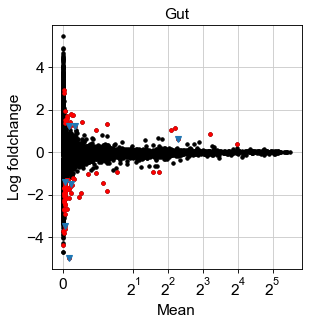

<Figure size 400x400 with 0 Axes>

In [60]:
for pop in list_common:
    print(pop) #put celltype here
    adata_rid = adata[adata.obs['celltype.mapped'] == pop,:].copy() 
    sc.tl.rank_genes_groups(adata_rid, groupby='tdTom', groups=['pos','neg'], method='wilcoxon', key = "wilcoxon")
    df1 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['names'])
    df2 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['pvals_adj'])
    df3 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['logfoldchanges'])
    df4 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['scores'])

    df2.index = list(df1.pos)
    df5 = df2.copy()
    df5.index = list(df1.neg)
    df3.index = list(df1.pos)

    df6 = df3.copy()
    df6.index = list(df1.neg)
    
    ## foldchange = []
    mean = []
    foldchange = []
    foldchange_sig = [] #to highlight significant genes
    mean_sig = []
    mean_wti = []
    flc_wti = []
    genes_sig = []
    dfn = [str(x) for x in list(overlap_genes[pop + '_neg_g']) if str(x)!='nan']
    dfp = [str(x) for x in list(overlap_genes[pop + '_pos_g']) if str(x)!='nan']


    for i in df2.index[:5000]: #len(adata_rid.var_names
         mean_wt = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'neg',i].X) #mean expression in WT
         mean_ko = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'pos',i].X) #mean expression in KO
         fc = np.log2(mean_ko/mean_wt)    #foldchange
         av = (mean_wt*mean_ko) #average expression
         #av = mean_wt #or just this
         foldchange.append(fc)
         mean.append(av)


         if df2.loc[i][0] < 0.1 and df3.loc[i][0] > 1.5:
             foldchange_sig.append(fc)
             mean_sig.append(av)
             genes_sig.append(i)

             if i in dfp:
                 mean_wti.append(av)
                 flc_wti.append(fc)

    for i in df5.index[:5000]: #len(adata_rid.var_names
         mean_wt = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'neg',i].X) #mean expression in WT
         mean_ko = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'pos',i].X) #mean expression in KO            
         fc1 = np.log2(mean_ko/mean_wt)    #foldchange
         av1 = (mean_ko*mean_wt) #average expression
         #av = mean_wt #or just this
         foldchange.append(fc1)
         mean.append(av1)


         if df5.loc[i][1] < 0.1 and df6.loc[i][1] > 1.5:
             foldchange_sig.append(fc1)
             mean_sig.append(av1)
             genes_sig.append(i)


             if i in dfn:
                 mean_wti.append(av1)
                 flc_wti.append(fc1)


    #now plot
    plt.plot(mean, foldchange, 'k.')
    plt.plot(mean_sig, foldchange_sig, 'r.') 
    plt.plot(mean_wti, flc_wti, 'v')
    #for i in range(len(genes_sig)):
        #plt.annotate(genes_sig[i], (mean_sig[i], foldchange_sig[i]), size=5)
    plt.xlabel('Mean')
    plt.ylabel('Log foldchange')
    plt.title(pop)
    plt.xscale('symlog', basex=2)
    texts = []
    plt.savefig(output_dr + '{}'.format(pop)+'_no_annot_MAplot.png')
    plt.figure(figsize=(5,5))
    #plt.show()            

In [149]:
list_uncommon = [pop for pop in df_good.index if pop not in df_good_wt.index]

list_uncommon

['Allantois', 'Cardiomyocytes', 'Def. endoderm', 'Neural crest']

In [61]:
list_uncommon = ['Allantois', 'Cardiomyocytes', 'Def. endoderm', 'Neural crest']

Allantois


ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:06)
<ipython-input-62-d32238af8cd0>:32: RuntimeWarning: divide by zero encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-62-d32238af8cd0>:32: RuntimeWarning: invalid value encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-62-d32238af8cd0>:48: RuntimeWarning: divide by zero encountered in log2
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-62-d32238af8cd0>:48: RuntimeWarning: invalid value encountered in double_scalars
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-62-d32238af8cd0>:71: MatplotlibDepr

Cardiomyocytes


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)
<ipython-input-62-d32238af8cd0>:32: RuntimeWarning: divide by zero encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-62-d32238af8cd0>:32: RuntimeWarning: invalid value encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-62-d32238af8cd0>:48: RuntimeWarning: divide by zero encountered in log2
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-62-d32238af8cd0>:48: RuntimeWarning: invalid value encountered in double_scalars
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-62-d32238af8cd0>:71: MatplotlibDeprecationWarning

Def. endoderm


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
<ipython-input-62-d32238af8cd0>:32: RuntimeWarning: divide by zero encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-62-d32238af8cd0>:32: RuntimeWarning: invalid value encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-62-d32238af8cd0>:48: RuntimeWarning: divide by zero encountered in log2
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-62-d32238af8cd0>:48: RuntimeWarning: invalid value encountered in double_scalars
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-62-d32238af8cd0>:71: MatplotlibDeprecationWarning

Neural crest


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)
<ipython-input-62-d32238af8cd0>:32: RuntimeWarning: divide by zero encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-62-d32238af8cd0>:32: RuntimeWarning: invalid value encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-62-d32238af8cd0>:48: RuntimeWarning: divide by zero encountered in log2
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-62-d32238af8cd0>:48: RuntimeWarning: invalid value encountered in double_scalars
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-62-d32238af8cd0>:71: MatplotlibDeprecationWarning

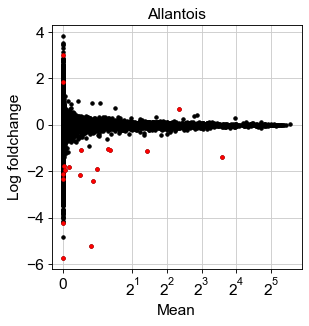

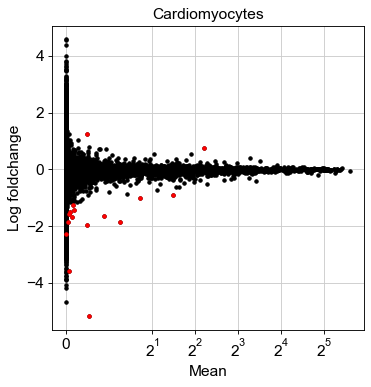

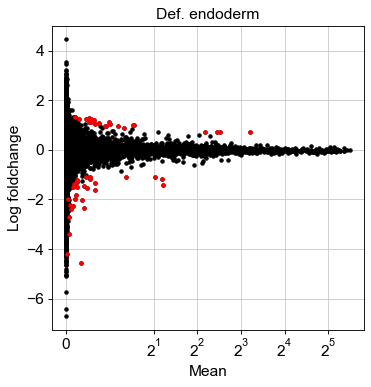

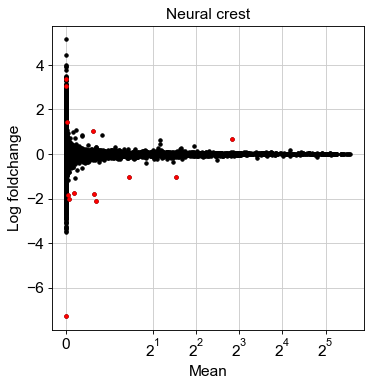

<Figure size 400x400 with 0 Axes>

In [62]:
#MA plots for the celltypes not in WTinjection
for pop in list_uncommon:
    print(pop)
    adata_rid = adata[adata.obs['celltype.mapped'] == pop,:].copy() 
    sc.tl.rank_genes_groups(adata_rid, groupby='tdTom', groups=['pos','neg'], method='wilcoxon', key = "wilcoxon")
    df1 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['names'])
    df2 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['pvals_adj'])
    df3 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['logfoldchanges'])
    df4 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['scores'])

    df2.index = list(df1.pos)
    df5 = df2.copy()
    df5.index = list(df1.neg)
    df3.index = list(df1.pos)

    df6 = df3.copy()
    df6.index = list(df1.neg)
    
    ## foldchange = []
    mean = []
    foldchange = []
    foldchange_sig = [] #to highlight significant genes
    mean_sig = []
    mean_wti = []
    flc_wti = []
    genes_sig = []


    for i in df2.index[:10000]: #len(adata_rid.var_names
         mean_wt = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'neg',i].X) #mean expression in WT
         mean_ko = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'pos',i].X) #mean expression in KO
         fc = np.log2(mean_ko/mean_wt)    #foldchange
         av = (mean_wt*mean_ko) #average expression
         #av = mean_wt #or just this
         foldchange.append(fc)
         mean.append(av)


         if df2.loc[i][0] < 0.1 and df3.loc[i][0] > 1.5:
             foldchange_sig.append(fc)
             mean_sig.append(av)
             genes_sig.append(i)


    for i in df5.index[:10000]: #len(adata_rid.var_names
         mean_wt = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'neg',i].X) #mean expression in WT
         mean_ko = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'pos',i].X) #mean expression in KO            
         fc1 = np.log2(mean_ko/mean_wt)    #foldchange
         av1 = (mean_ko*mean_wt) #average expression
         #av = mean_wt #or just this
         foldchange.append(fc1)
         mean.append(av1)


         if df5.loc[i][1] < 0.1 and df6.loc[i][1] > 1.5:
             foldchange_sig.append(fc1)
             mean_sig.append(av1)
             genes_sig.append(i)



    #now plot
    plt.plot(mean, foldchange, 'k.')
    plt.plot(mean_sig, foldchange_sig, 'r.') 
    plt.plot(mean_wti, flc_wti, 'v')
    #for i in range(len(genes_sig)):
        #plt.annotate(genes_sig[i], (mean_sig[i], foldchange_sig[i]), size=5)
    plt.xlabel('Mean')
    plt.ylabel('Log foldchange')
    plt.title(pop)
    plt.xscale('symlog', basex=2)
    texts = []
    plt.savefig(output_dr + '{}'.format(pop)+'_MAplot.png')
    plt.figure(figsize=(5,5))
    #plt.show()            

# haem_subclust

In [154]:
adata.obs

,sample,stage,barcode,sequencing.batch,stripped,doublet,theiler,doub.density,cluster,cluster.sub,...,endo_gutDPT,endo_gutCluster,weight,stage.mapped,celltype.mapped,closest.cell,sizeFactor,tdTom,haem_subclust.mapped,meso.mapped
cell,,,,,,,,,,,,,,,,,,,,,
chim_cell_1,mixl_1,E8.5,AAACCCAAGCATAGGC,1,False,False,nan,NaN,NaN,NaN,...,NaN,nan,139332,E8.25,Paraxial mesoderm,atlas_cell_74754,1.223278,neg,nan,NaN
chim_cell_2,mixl_1,E8.5,AAACCCAAGGGACTGT,1,False,False,nan,NaN,NaN,NaN,...,NaN,nan,139333,E8.5,Erythroid3,atlas_cell_134274,0.970827,neg,Ery3,NaN
chim_cell_3,mixl_1,E8.5,AAACCCACAAGCAATA,1,False,False,nan,NaN,NaN,NaN,...,NaN,nan,139334,E8.25,Pharyngeal mesoderm,atlas_cell_93757,1.214652,neg,nan,NaN
chim_cell_4,mixl_1,E8.5,AAACCCACATCTTCGC,1,False,False,nan,NaN,NaN,NaN,...,NaN,nan,139335,E8.25,Forebrain/Midbrain/Hindbrain,atlas_cell_92424,0.985727,neg,nan,NaN
chim_cell_5,mixl_1,E8.5,AAACCCAGTATCTCTT,1,False,False,nan,NaN,NaN,NaN,...,NaN,nan,139336,E8.5,Forebrain/Midbrain/Hindbrain,atlas_cell_38846,0.763538,neg,nan,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chim_cell_43819,mixl_6,E8.5,TTTGGTTTCGGACCAC,1,False,False,nan,NaN,NaN,NaN,...,NaN,nan,183150,E8.0,Intermediate mesoderm,atlas_cell_121130,1.029452,pos,nan,NaN
chim_cell_43821,mixl_6,E8.5,TTTGTTGGTCACTTAG,1,False,False,nan,NaN,NaN,NaN,...,NaN,nan,183152,E8.25,Paraxial mesoderm,atlas_cell_63302,1.902155,pos,nan,NaN
chim_cell_43822,mixl_6,E8.5,TTTGTTGGTCCGACGT,1,False,False,nan,NaN,NaN,NaN,...,NaN,nan,183153,E8.5,Neural crest,atlas_cell_102526,0.839001,pos,nan,NaN


In [96]:
df = pd.crosstab(adata.obs['haem_subclust.mapped'], adata.obs['tdTom'])
vec = np.array((df.neg>=0) & (df.pos>=0))
print(vec)
df_good = df.loc[vec] #df.iloc[vec] does not work for one reason I don't understand, but df.loc[voc] takes away index
print(df_good)
print(df_good.dtypes)

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True]
tdTom                   neg    pos
haem_subclust.mapped              
BP1                       0      1
BP2                      75     95
BP3                      54     66
BP4                      41     42
EC8                       0      1
Ery1                     64    126
Ery2                    305    452
Ery3                   1832    455
Ery4                   1569    372
Haem2                     3     12
Haem3                     4      3
Haem4                    10     20
Mk                       80     57
My                       13     30
nan                   14057  17369
tdTom
neg    int64
pos    int64
dtype: object


In [156]:
#WT
df = pd.crosstab(adata_wt.obs['haem_subclust.mapped'], adata_wt.obs['tdTom'])
#df = df.rename(columns={0: "neg", 1: "pos"})
vec = np.array((df.neg>=50) & (df.pos>=50))
print(vec)
df_good_wt = df.loc[vec] #df.iloc[vec] does not work for one reason I don't understand, but df.loc[voc] takes away index
print(df_good_wt)
print(df_good_wt.dtypes)


list_common = [pop for pop in df_good.index if pop in df_good_wt.index]
list_common

[ True  True False False False  True False False False False False False
 False  True  True  True False  True  True False False False False False
  True]
tdTom                  neg   pos
haem_subclust.mapped            
BP1                    120   138
BP2                    128   108
EC2                     71   129
Ery2                    59   150
Ery3                    85    83
Ery4                    57    77
Haem2                   72    91
Haem3                   58    52
nan                   4785  6733
tdTom
neg    int64
pos    int64
dtype: object


['BP2', 'Ery2', 'Ery3', 'Ery4', 'nan']

In [175]:
list_uncommon = [pop for pop in df_good.index if pop not in df_good_wt.index]
list_uncommon

['BP3', 'Ery1', 'Mk']

In [157]:
final = pd.read_csv('C:/Users/aamw4/home/aamw4/chim_DEGs_final', header = [0,1], sep = ",")
df_chim = pd.read_csv('C:/Users/aamw4/home/aamw4/chim_DEGs_haem.csv')
df_wt = pd.read_csv('C:/Users/aamw4/home/aamw4/wt_chim_DEGs_final_haem')

In [161]:
df_wt

,celltype,BP1,BP1.1,BP2,BP2.1,EC2,EC2.1,Ery1,Ery1.1,Ery2,...,Ery4,Ery4.1,Haem1,Haem1.1,Haem2,Haem2.1,Haem3,Haem3.1,nan,nan.1
0,tdTom,pos,neg,pos,neg,pos,neg,pos,neg,pos,...,pos,neg,pos,neg,pos,neg,pos,neg,pos,neg
1,0,4933404O12Rik,Ttr,Erdr1,Cdkn1c,Erdr1,Xist,Gm13225,Xist,Gm13225,...,4933404O12Rik,Xist,Erdr1,Cdkn1c,Erdr1,Cdkn1c,Erdr1,Xist,Gm13225,G430049J08Rik
2,1,Gm13154,Xist,Mid1,Phlda2,Smagp,Cdkn1c,Hist1h1e,Phlda2,Hist1h1a,...,Hist1h1e,Cdkn1c,Mcts2,Phlda2,Impact,Xist,Kcnq1ot1,Phlda2,Gm5678,Olfr1459
3,2,Erdr1,Cdkn1c,4933404O12Rik,Rhox5,Mid1,Phlda2,Hist1h1a,Dusp9,Gm13154,...,Hist1h1b,Ttr,Rhox5,Spink1,Mid1,Phlda2,Mcts2,Rhox5,4933404O12Rik,Prss44
4,3,St3gal6,Phlda2,Kcnq1ot1,Spink1,Slc38a4,Spink1,4933404O12Rik,Apoe,4933404O12Rik,...,Hist1h1a,Akr1e1,Spink1,Rhox5,Kcnq1ot1,Apoa1,Pcnp,Cdkn1c,A530016L24Rik,Gm9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6575,6574,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Rhox1,Erdr1
6576,6575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Gm9,A530016L24Rik
6577,6576,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prss44,4933404O12Rik
6578,6577,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Olfr1459,Gm5678


In [158]:
unique_genes = pd.DataFrame()

for pop in list_common:    
    dfn = [gene for gene in list(df_chim[pop + '.1']) if gene not in list(df_wt[pop + '.1'])]
    dfp = [gene for gene in list(df_chim[pop]) if gene not in list(df_wt[pop])]
    unique_genes[pop + '_neg_g'] = pd.Series(dfn)
    unique_genes[pop + '_pos_g'] = pd.Series(dfp)
unique_genes

KeyError: 'nan.1'

In [159]:
unique_genes

,BP2_neg_g,BP2_pos_g,Ery2_neg_g,Ery2_pos_g,Ery3_neg_g,Ery3_pos_g,Ery4_neg_g,Ery4_pos_g
0,Grb10,H19,Grb10,Hopx,Grb10,Hopx,Grb10,Gm13225
1,Hbb-y,Bex1,Gm28049,Impact,Gm28049,Gm13154,Gm28049,Hopx
2,Hba-x,Fabp5,Tnni1,Bex1,Fgfrl1,Peg10,Hemgn,Impact
3,Tmsb4x,NaN,Taok3,Mcts2,Egr1,Impact,Plxnd1,Mest
4,Hba-a1,NaN,Acp5,Fn1,Aqp3,Slc38a4,Apobec3,Mcts2
5,Slc38a5,NaN,Pon2,Peg3,Sgk3,Mest,Csf2rb,Homer2
6,Scand1,NaN,Rgs10,Mt1,5730508B09Rik,Mcts2,Hbb-bs,Pcbp4
7,Hbb-bh1,NaN,Redrum,Bmyc,Kel,Prtg,B930036N10Rik,Hk2
8,S100a10,NaN,Aqp8,Shmt2,Rhd,Nnat,Ermap,E130012A19Rik
9,Rpl21,NaN,Tomm22,Wars,Ermap,Peg3,Cd59a,Cep290


In [60]:
unique_genes.to_csv('C:/Users/aamw4/home/aamw4/DEG_unique_genes_haem.csv')

In [162]:
overlap_genes = pd.DataFrame()

for pop in list_common:    
    dfn = [gene for gene in list(df_chim[pop + '.1']) if gene in list(df_wt[pop + '.1'])]
    dfp = [gene for gene in list(df_chim[pop]) if gene in list(df_wt[pop])]
    overlap_genes[pop + '_neg_g'] = pd.Series(dfn)
    overlap_genes[pop + '_pos_g'] = pd.Series(dfp)
overlap_genes

KeyError: 'nan.1'

In [163]:
overlap_genes

,BP2_neg_g,BP2_pos_g,Ery2_neg_g,Ery2_pos_g,Ery3_neg_g,Ery3_pos_g,Ery4_neg_g,Ery4_pos_g
0,neg,pos,neg,pos,neg,pos,neg,pos
1,Car2,Impact,Xist,Gm13225,Xist,Gm13225,Hbb-y,4933404O12Rik
2,Tomm22,Erdr1,Akr1e1,4933404O12Rik,Akr1e1,4933404O12Rik,Akr1e1,Erdr1
3,NaN,Kcnq1ot1,Lamtor3,Erdr1,Pklr,Erdr1,Slc4a1,Slc38a4
4,NaN,Mcts2,Scand1,Kcnq1ot1,Hbb-y,Mid1,Hba-a2,Peg3
...,...,...,...,...,...,...,...,...
62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [63]:
overlap_genes.to_csv('C:/Users/aamw4/home/aamw4/DEG_overlap_genes_haem.csv')

ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


BP2


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
<ipython-input-171-12abbb848007>:33: RuntimeWarning: divide by zero encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-171-12abbb848007>:33: RuntimeWarning: invalid value encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-171-12abbb848007>:52: RuntimeWarning: divide by zero encountered in log2
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-171-12abbb848007>:52: RuntimeWarning: invalid value encountered in double_scalars
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-171-12abbb848007>:79: MatplotlibDeprecationWa

Ery2


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)
<ipython-input-171-12abbb848007>:33: RuntimeWarning: divide by zero encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-171-12abbb848007>:33: RuntimeWarning: invalid value encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-171-12abbb848007>:52: RuntimeWarning: divide by zero encountered in log2
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-171-12abbb848007>:52: RuntimeWarning: invalid value encountered in double_scalars
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-171-12abbb848007>:79: MatplotlibDeprecationWa

...

Ery4


ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:03)
<ipython-input-171-12abbb848007>:33: RuntimeWarning: divide by zero encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-171-12abbb848007>:33: RuntimeWarning: invalid value encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-171-12abbb848007>:52: RuntimeWarning: divide by zero encountered in log2
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-171-12abbb848007>:52: RuntimeWarning: invalid value encountered in double_scalars
  f

nan


ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:01:31)


KeyError: 'nan_neg_g'

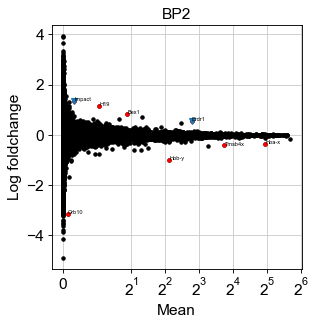

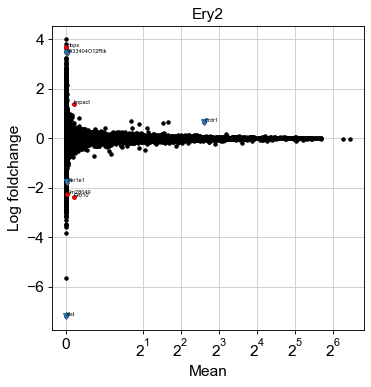

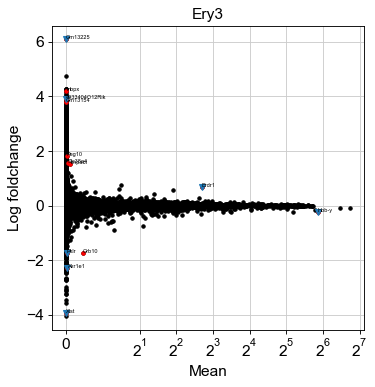

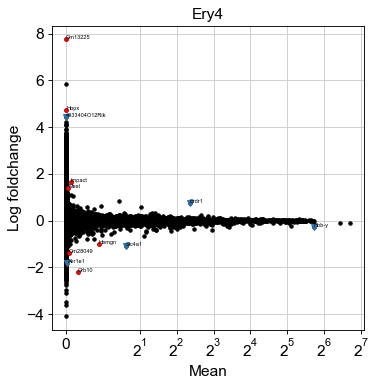

<Figure size 400x400 with 0 Axes>

In [171]:
for pop in list_common:
    print(pop) #put celltype here
    adata_rid = adata[adata.obs['haem_subclust.mapped'] == pop,:].copy() 
    sc.tl.rank_genes_groups(adata_rid, groupby='tdTom', groups=['pos','neg'], method='wilcoxon', key = "wilcoxon")
    df1 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['names'])
    df2 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['pvals_adj'])
    df3 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['logfoldchanges'])
    df4 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['scores'])

    df2.index = list(df1.pos)
    df5 = df2.copy()
    df5.index = list(df1.neg)
    df3.index = list(df1.pos)

    df6 = df3.copy()
    df6.index = list(df1.neg)
    
    ## foldchange = []
    mean = []
    foldchange = []
    foldchange_sig = [] #to highlight significant genes
    mean_sig = []
    mean_wti = []
    flc_wti = []
    genes_sig = []
    dfn = [str(x) for x in list(overlap_genes[pop + '_neg_g']) if str(x)!='nan']
    dfp = [str(x) for x in list(overlap_genes[pop + '_pos_g']) if str(x)!='nan']


    for i in df2.index[:10000]: #len(adata_rid.var_names
         mean_wt = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'neg',i].X) #mean expression in WT
         mean_ko = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'pos',i].X) #mean expression in KO
         fc = np.log2(mean_ko/mean_wt)    #foldchange
         av = (mean_wt*mean_ko) #average expression
         #av = mean_wt #or just this
         foldchange.append(fc)
         mean.append(av)


         if df2.loc[i][0] < 0.1 and df3.loc[i][0] > 1.5:
             foldchange_sig.append(fc)
             mean_sig.append(av)
             genes_sig.append(i)

             if i in dfp:
                 mean_wti.append(av)
                 flc_wti.append(fc)

    for i in df5.index[:10000]: #len(adata_rid.var_names
         mean_wt = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'neg',i].X) #mean expression in WT
         mean_ko = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'pos',i].X) #mean expression in KO            
         fc1 = np.log2(mean_ko/mean_wt)    #foldchange
         av1 = (mean_ko*mean_wt) #average expression
         #av = mean_wt #or just this
         foldchange.append(fc1)
         mean.append(av1)


         if df5.loc[i][1] < 0.1 and df6.loc[i][1] > 1.5:
             foldchange_sig.append(fc1)
             mean_sig.append(av1)
             genes_sig.append(i)


             if i in dfn:
                 mean_wti.append(av1)
                 flc_wti.append(fc1)


    #now plot
    plt.plot(mean, foldchange, 'k.')
    plt.plot(mean_sig, foldchange_sig, 'r.') 
    plt.plot(mean_wti, flc_wti, 'v')
    for i in range(len(genes_sig)):
        plt.annotate(genes_sig[i], (mean_sig[i], foldchange_sig[i]), size=5)
    plt.xlabel('Mean')
    plt.ylabel('Log foldchange')
    plt.title(pop)
    plt.xscale('symlog', basex=2)
    texts = []
    plt.savefig(output_dr + '{}'.format(pop)+'_MAplot.png')
    plt.figure(figsize=(5,5))
    #plt.show()            

ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


BP3


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
<ipython-input-177-1c691b25f530>:32: RuntimeWarning: divide by zero encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-177-1c691b25f530>:32: RuntimeWarning: invalid value encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-177-1c691b25f530>:48: RuntimeWarning: divide by zero encountered in log2
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-177-1c691b25f530>:48: RuntimeWarning: invalid value encountered in double_scalars
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-177-1c691b25f530>:71: MatplotlibDeprecationWa

Ery1


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
<ipython-input-177-1c691b25f530>:32: RuntimeWarning: divide by zero encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-177-1c691b25f530>:32: RuntimeWarning: invalid value encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-177-1c691b25f530>:48: RuntimeWarning: divide by zero encountered in log2
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-177-1c691b25f530>:48: RuntimeWarning: invalid value encountered in double_scalars
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-177-1c691b25f530>:71: MatplotlibDeprecationWa

Mk


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
<ipython-input-177-1c691b25f530>:32: RuntimeWarning: divide by zero encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-177-1c691b25f530>:32: RuntimeWarning: invalid value encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-177-1c691b25f530>:48: RuntimeWarning: divide by zero encountered in log2
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-177-1c691b25f530>:48: RuntimeWarning: invalid value encountered in double_scalars
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-177-1c691b25f530>:71: MatplotlibDeprecationWa

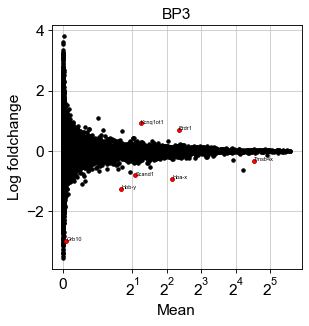

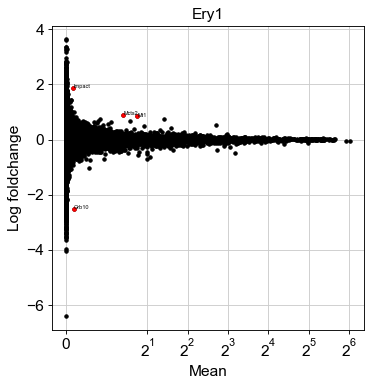

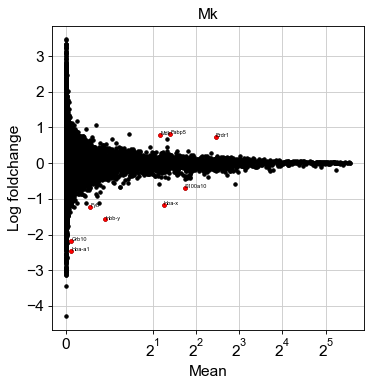

<Figure size 400x400 with 0 Axes>

In [177]:
#MA plots for the celltypes not in WTinjection
for pop in list_uncommon:
    print(pop)
    adata_rid = adata[adata.obs['haem_subclust.mapped'] == pop,:].copy() 
    sc.tl.rank_genes_groups(adata_rid, groupby='tdTom', groups=['pos','neg'], method='wilcoxon', key = "wilcoxon")
    df1 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['names'])
    df2 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['pvals_adj'])
    df3 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['logfoldchanges'])
    df4 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['scores'])

    df2.index = list(df1.pos)
    df5 = df2.copy()
    df5.index = list(df1.neg)
    df3.index = list(df1.pos)

    df6 = df3.copy()
    df6.index = list(df1.neg)
    
    ## foldchange = []
    mean = []
    foldchange = []
    foldchange_sig = [] #to highlight significant genes
    mean_sig = []
    mean_wti = []
    flc_wti = []
    genes_sig = []


    for i in df2.index[:10000]: #len(adata_rid.var_names
         mean_wt = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'neg',i].X) #mean expression in WT
         mean_ko = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'pos',i].X) #mean expression in KO
         fc = np.log2(mean_ko/mean_wt)    #foldchange
         av = (mean_wt*mean_ko) #average expression
         #av = mean_wt #or just this
         foldchange.append(fc)
         mean.append(av)


         if df2.loc[i][0] < 0.1 and df3.loc[i][0] > 1.5:
             foldchange_sig.append(fc)
             mean_sig.append(av)
             genes_sig.append(i)


    for i in df5.index[:10000]: #len(adata_rid.var_names
         mean_wt = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'neg',i].X) #mean expression in WT
         mean_ko = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'pos',i].X) #mean expression in KO            
         fc1 = np.log2(mean_ko/mean_wt)    #foldchange
         av1 = (mean_ko*mean_wt) #average expression
         #av = mean_wt #or just this
         foldchange.append(fc1)
         mean.append(av1)


         if df5.loc[i][1] < 0.1 and df6.loc[i][1] > 1.5:
             foldchange_sig.append(fc1)
             mean_sig.append(av1)
             genes_sig.append(i)



    #now plot
    plt.plot(mean, foldchange, 'k.')
    plt.plot(mean_sig, foldchange_sig, 'r.') 
    plt.plot(mean_wti, flc_wti, 'v')
    for i in range(len(genes_sig)):
        plt.annotate(genes_sig[i], (mean_sig[i], foldchange_sig[i]), size=5)
    plt.xlabel('Mean')
    plt.ylabel('Log foldchange')
    plt.title(pop)
    plt.xscale('symlog', basex=2)
    texts = []
    plt.savefig(output_dr + '{}'.format(pop)+'_MAplot.png')
    plt.figure(figsize=(5,5))
    #plt.show()            

In [ ]:
def create_tuple_for_for_columns(df_a, multi_level_col):
    """
    Create a columns tuple that can be pandas MultiIndex to create multi level column

    :param df_a: pandas dataframe containing the columns that must form the first level of the multi index
    :param multi_level_col: name of second level column
    :return: tuple containing (second_level_col, firs_level_cols)
    """
    temp_columns = []
    for item in df_a.columns:
        temp_columns.append((multi_level_col, item))
    return temp_columns

In [ ]:
sc.settings.figdir = '/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plots/heatmaps/'
ran = range(0,77)
df_deg = pd.DataFrame().reindex(ran) #initialization of df_dea #ValueError: Cannot set a frame with no defined index and a value that cannot be converted to a Series
df_deg.dropna(inplace=True)
number_genes = []
final = pd.DataFrame()

for pop in list(df_good.index):
    print(pop)
    adata_rid = adata[adata.obs['haem_subclust.mapped'] == pop,:].copy()
    sc.tl.rank_genes_groups(adata_rid, groupby='tdTom', groups=['pos','neg'], method='wilcoxon', key = "wilcoxon")
    df1 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['names'])
    df2 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['pvals_adj'])
    df3 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['logfoldchanges'])

    
    vec_up = np.where((df3['pos']>=np.log2(1.5)) & (df2['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
    vec_down = np.where((df3['neg']>= np.log2(1.5)) & (df2['neg']<= 0.1) )[0]
    
        
    df_pos = pd.DataFrame(df2.loc[vec_up]['pos'])
    df_pos.index = list(df1.loc[vec_up]['pos'])
    df_pos['lfc'] = list(df3.loc[vec_up]['pos'])
    df_pos = df_pos.sort_values(by='lfc',ascending=False)

 
    df_neg = pd.DataFrame(df2.loc[vec_down]['neg'])
    df_neg.index = list(df1.loc[vec_down]['neg'])
    df_neg['lfc'] = list(df3.loc[vec_down]['neg'])
    df_neg = df_neg.sort_values(by='lfc',ascending=False)

 
    lista_n = df_neg.index
    lista_p = df_pos.index
 
    print(len(lista_p))
    print(len(lista_n))
    
    number_pos = len(lista_p)
    number_neg = len(lista_n)
    
    number_genes.append(number_pos)
    number_genes.append(number_neg)
    
    #make a list with lengths of all lists, sort and take maximum
    
    list_pos = lista_p.tolist() #format to list to add to dataframe
    list_neg = lista_n.tolist()
    
    #create DataFrame final with only gene names according to celltype and tdTom 
    
    df_posi = pd.DataFrame({'pos': list_pos})
    df_nega = pd.DataFrame({'neg': list_neg})
    
    
    columns = create_tuple_for_for_columns(df_posi, pop)
    df_posi.columns = pd.MultiIndex.from_tuples(columns)
    
    index = pd.MultiIndex.from_tuples(df_posi, names=['celltype', 'tdTom'])
    df_posi.columns = index
    
    columns = create_tuple_for_for_columns(df_nega, pop)
    df_nega.columns = pd.MultiIndex.from_tuples(columns)
    
    index = pd.MultiIndex.from_tuples(df_nega, names=['celltype', 'tdTom'])
    df_nega.columns = index 

    df_pn = pd.concat([df_posi, df_nega], axis=1)
    index = pd.MultiIndex.from_tuples(df_pn, names=['celltype', 'tdTom'])
    df_pn.columns = index
    
    final = pd.concat([final, df_pn], axis=1)
    
    adata_rid.var_names_make_unique()
    
    if len(df_posi) > 20:
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,0].head(20), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_pos.png' )
    else : 
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,0].head(len(df_posi)), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_pos.png' )
            
    if len(df_nega) > 20:
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,1].head(20), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_neg.png' )
    else:
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,1].head(len(df_nega)), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_neg.png' )
   
    
print('finished ranking genes')
number_genes.sort(reverse=True)
number_genes[0] #prints highest number of selected genes for any celltype population to adapt range accordingly of df-Dea in initialisation

In [ ]:
final.to_csv(out_folder + 'chim_DEGs_haem.csv')

In [ ]:
sc.settings.figdir = '/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plots/heatmaps/'
ran = range(0,200)
df_dea = pd.DataFrame().reindex(ran) #initialization of df_dea #ValueError: Cannot set a frame with no defined index and a value that cannot be converted to a Series
df_dea.dropna(inplace=True)
number_genes = []


for pop in list(df_good.index):
    print(pop)
    adata_rid = adata[adata.obs['celltype.mapped'] == pop,:].copy()
    sc.tl.rank_genes_groups(adata_rid, groupby='tdTom', groups=['pos','neg'], method='wilcoxon', n_genes=10000, key = "wilcoxon")
    df1 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['names'])
    df2 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['pvals_adj'])
    df3 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['logfoldchanges'])
    df4 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['scores'])

    
    vec_up = np.where((df3['pos']>=np.log2(1.5)) & (df2['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
    vec_down = np.where((df3['neg']>= np.log2(1.5)) & (df2['neg']<= 0.1) )[0]
    
        
    df_pos = pd.DataFrame(df2.loc[vec_up]['pos'])
    df_pos.index = list(df1.loc[vec_up]['pos'])
    df_pos['lfc'] = list(df3.loc[vec_up]['pos'])
    df_pos = df_pos.sort_values(by='lfc',ascending=False)

 
    df_neg = pd.DataFrame(df2.loc[vec_down]['neg'])
    df_neg.index = list(df1.loc[vec_down]['neg'])
    df_neg['lfc'] = list(df3.loc[vec_down]['neg'])
    df_neg = df_neg.sort_values(by='lfc',ascending=False)

 
    lista_n = df_neg.index
    lista_p = df_pos.index
 
    print(len(lista_p))
    print(len(lista_n))
    
    number_pos = len(lista_p)
    number_neg = len(lista_n)
    
    number_genes.append(number_pos)
    number_genes.append(number_neg)
    
    #make a list with lengths of all lists, sort and take maximum
    
    list_pos = lista_p.tolist() #format to list to add to dataframe
    list_neg = lista_n.tolist()
    
    ##create df_dea with gene names, pvaladj and lfc
           
    df_dea[pop + '_pos_g'] = pd.Series(list_pos) #to avoid errors from different lengths, convert to Series
    df_dea[pop + '_pos_pvaladj'] = pd.Series(list(df_pos['pos']))
    df_dea[pop + '_pos_lfc'] = pd.Series(list(df_pos['lfc']))
    
    
    df_dea[pop + '_neg_g'] = pd.Series(list_neg)
    df_dea[pop + '_neg_pvaladj'] = pd.Series(list(df_neg['neg']))
    df_dea[pop + '_neg_lfc'] = pd.Series(list(df_neg['lfc']))
    
        
print('finished ranking genes')
number_genes.sort(reverse=True)
number_genes[0] #prints highest number of selected genes for any celltype population to adapt range accordingly of df-Dea in initialisation

# Meso subclust

In [178]:
df = pd.crosstab(adata.obs['meso.mapped'], adata.obs['tdTom'])
vec = np.array((df.neg>=50) & (df.pos>=50))
print(vec)
df_good = df.loc[vec] #df.iloc[vec] does not work for one reason I don't understand, but df.loc[voc] takes away index
print(df_good)
print(df_good.dtypes)

[False False  True False  True  True]
tdTom                neg  pos
meso.mapped                  
Head_mesoderm        252  134
Presomitic_mesoderm  167  239
Sclerotome           102  133
tdTom
neg    int64
pos    int64
dtype: object


In [81]:
df = pd.crosstab(adata_wt.obs['meso.mapped'], adata_wt.obs['tdTom'])
vec = np.array((df.neg>=0) & (df.pos>=0))
print(vec)
df_good_wt = df.loc[vec] #df.iloc[vec] does not work for one reason I don't understand, but df.loc[voc] takes away index
print(df_good_wt)
print(df_good_wt.dtypes)

[ True  True  True  True  True  True]
tdTom                   neg  pos
meso.mapped                     
Anterior-most_somites    11   23
Dermomyotome              8   17
Head_mesoderm            14   47
Posterior-most_somites   14   33
Presomitic_mesoderm      15   33
Sclerotome                4   16
tdTom
neg    int64
pos    int64
dtype: object


In [66]:
def create_tuple_for_for_columns(df_a, multi_level_col):
    """
    Create a columns tuple that can be pandas MultiIndex to create multi level column

    :param df_a: pandas dataframe containing the columns that must form the first level of the multi index
    :param multi_level_col: name of second level column
    :return: tuple containing (second_level_col, firs_level_cols)
    """
    temp_columns = []
    for item in df_a.columns:
        temp_columns.append((multi_level_col, item))
    return temp_columns

ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


Head_mesoderm


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


10
13


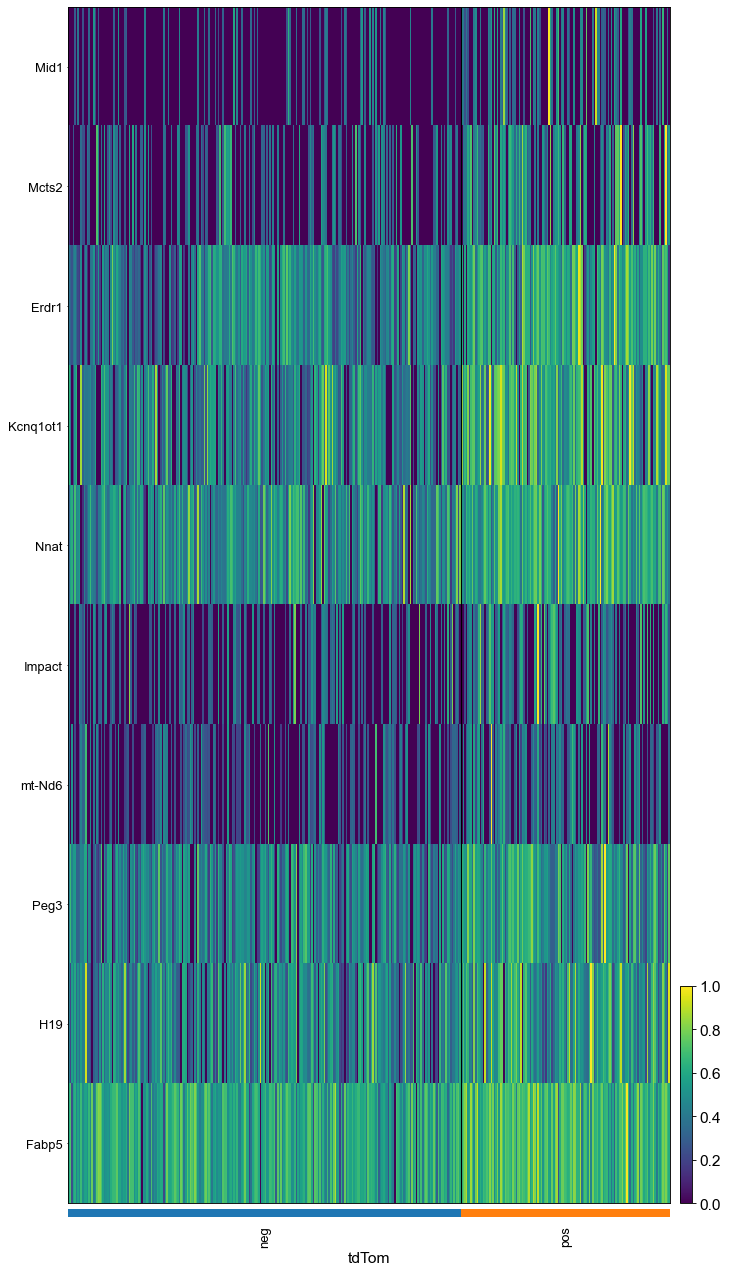

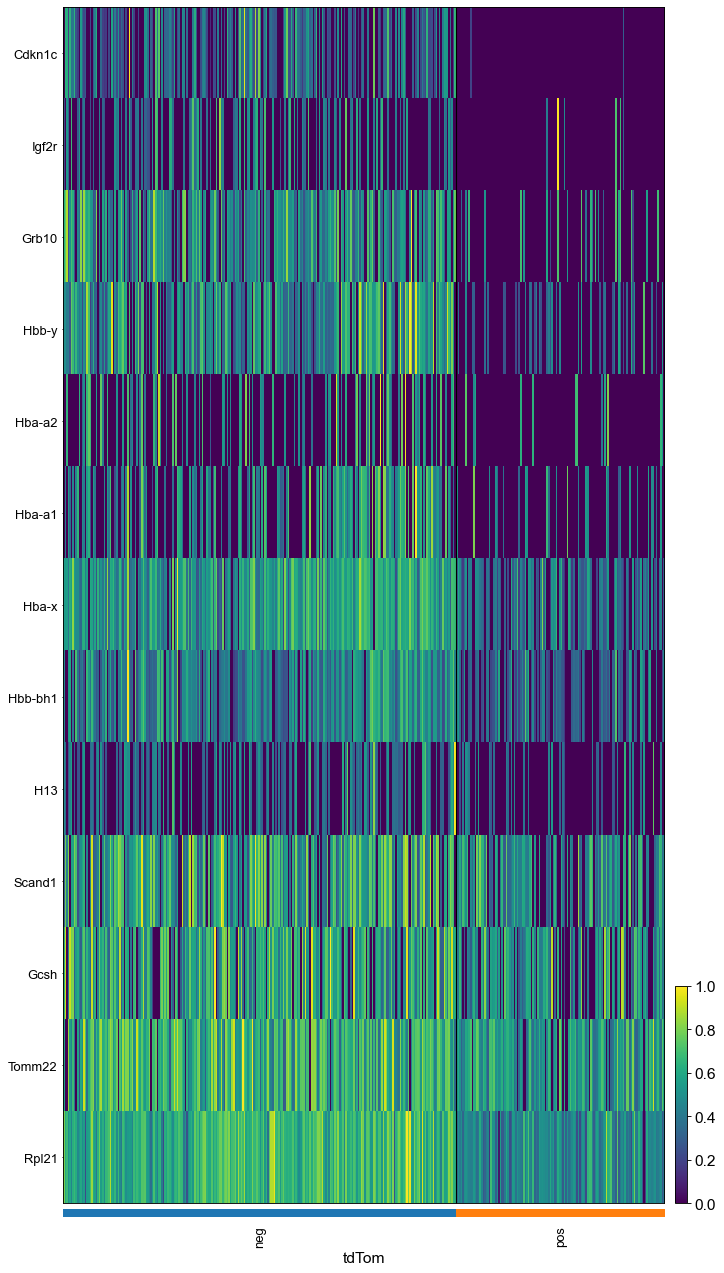

ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


Presomitic_mesoderm


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


8
14


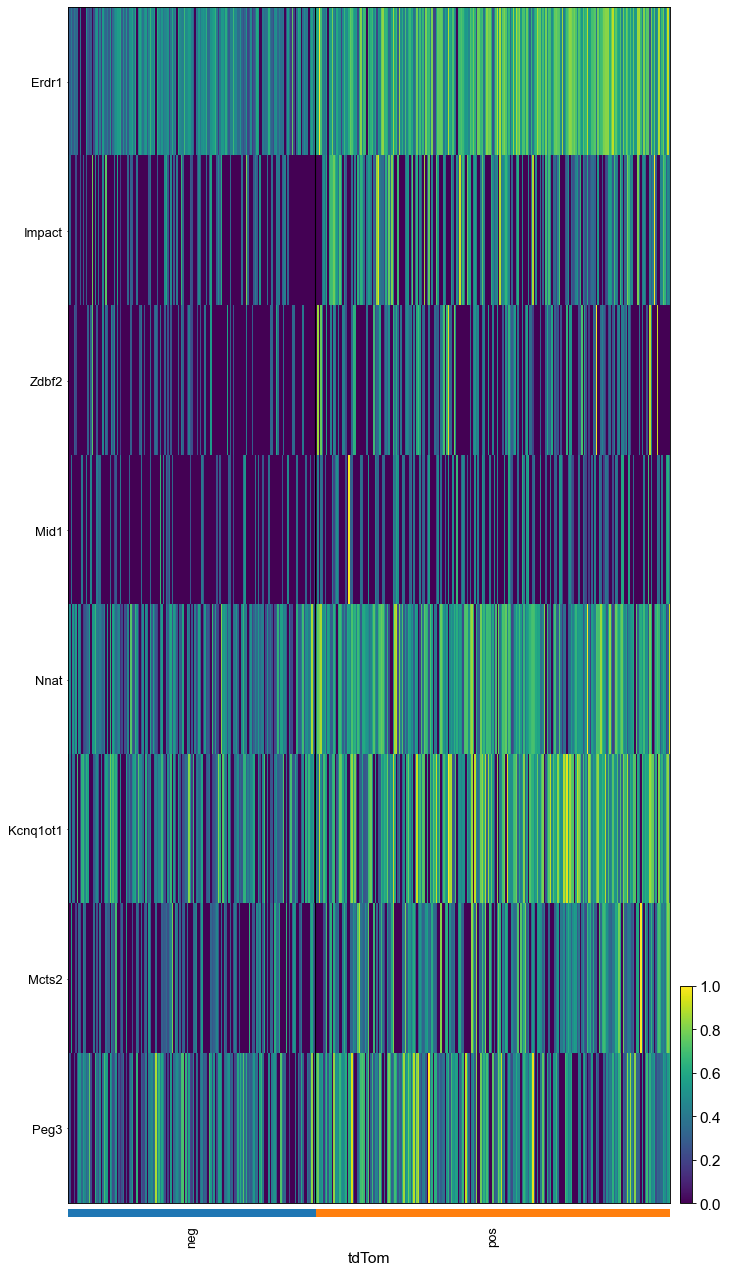

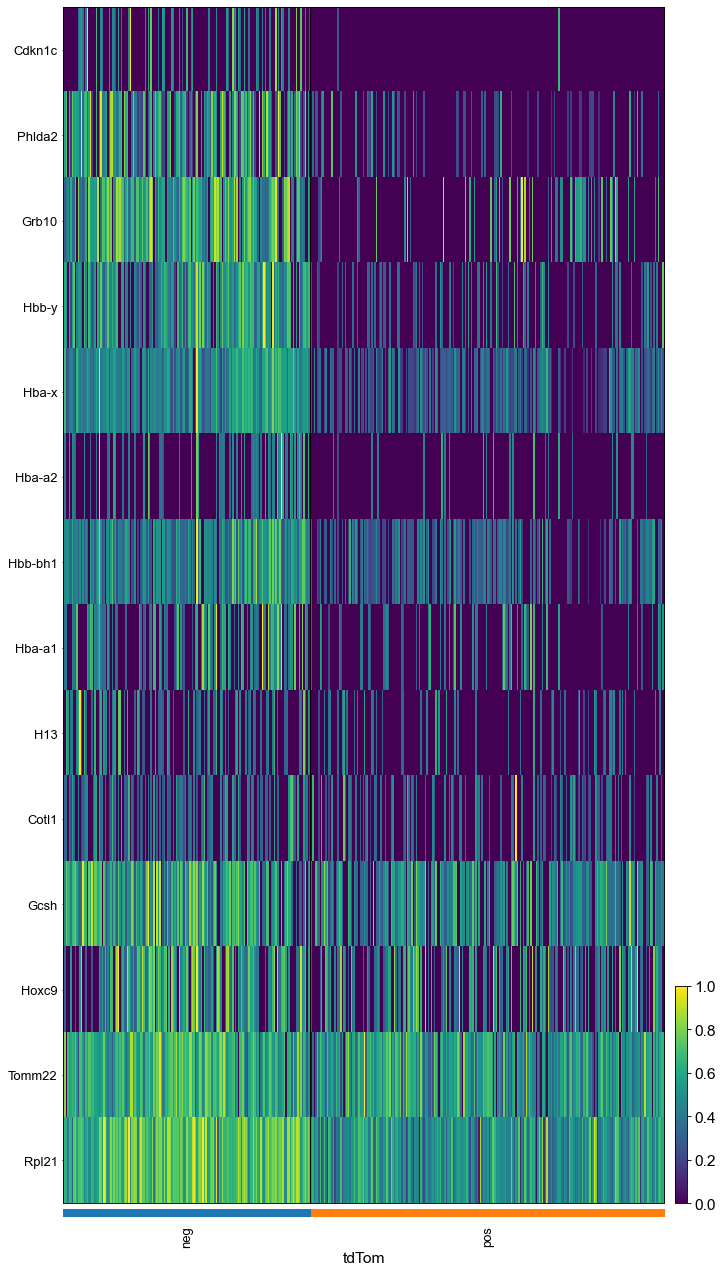

ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


Sclerotome


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


6
8


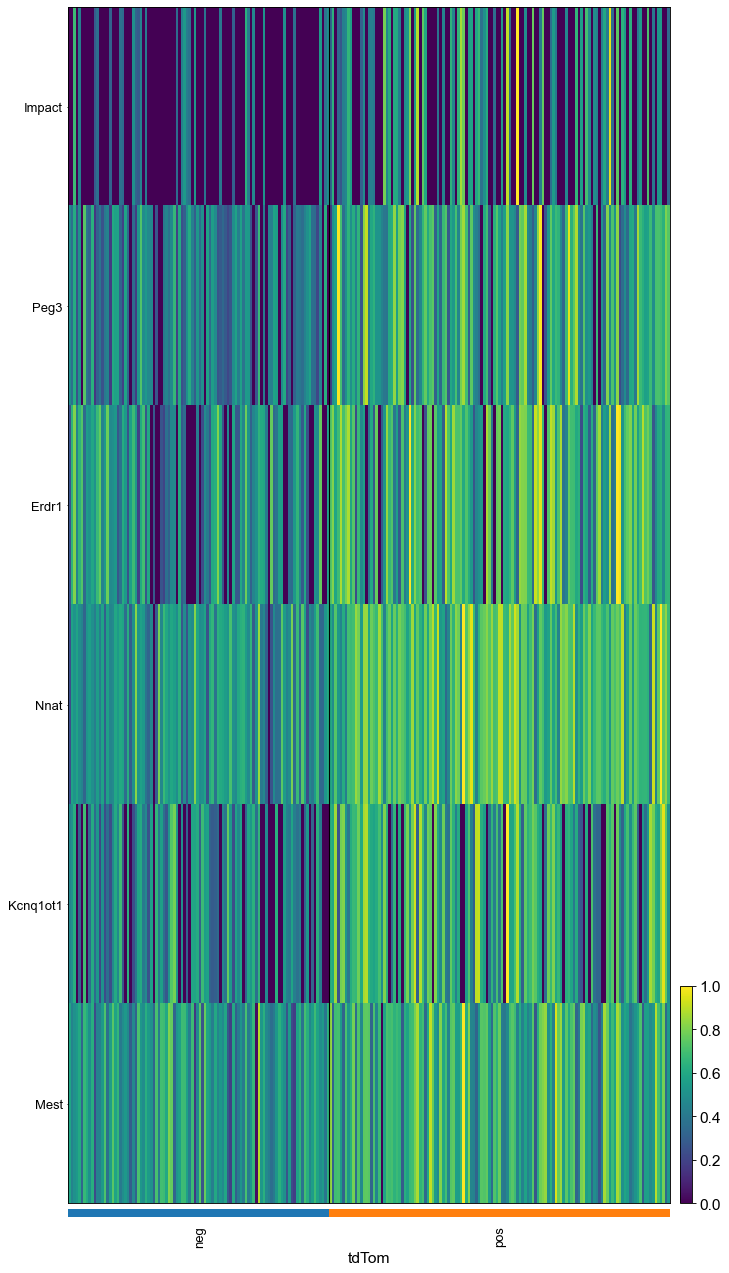

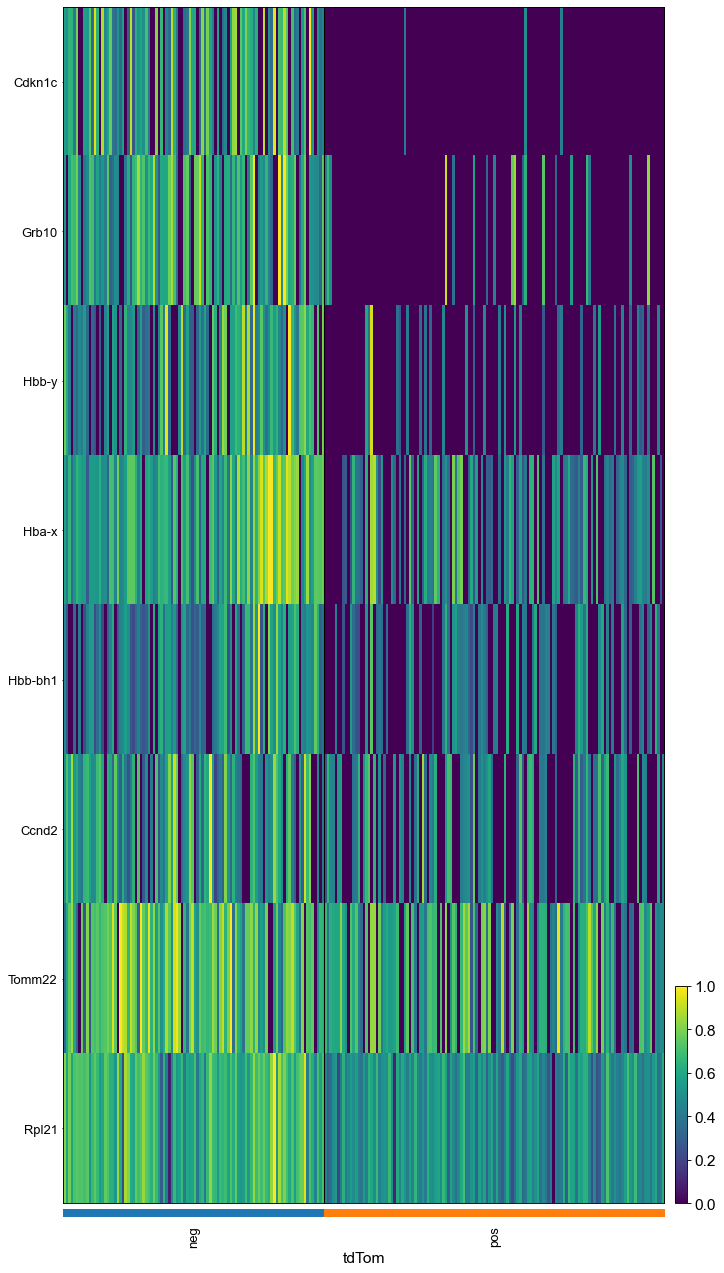

finished ranking genes


14

In [72]:
## different one to create DF only with gene names
#wt = pd.read_csv("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/data/wt_tomato_correlations_for_Melania.csv", index_col=1)
#list_names = [name for name in list(wt.index[0:100]) if name in adata.var_names]
sc.settings.figdir = 'C:/Users/aamw4/home/aamw4/plots/heatmaps/'
output_dr = 'C:/Users/aamw4/home/aamw4/plots/MAplots/'
number_genes = []
final = pd.DataFrame()

for pop in list(df_good.index):
    print(pop)
    adata_rid = adata[adata.obs['meso.mapped'] == pop,:].copy()
    sc.tl.rank_genes_groups(adata_rid, groupby='tdTom', groups=['pos','neg'], method='wilcoxon', key = "wilcoxon")
    df1 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['names'])
    df2 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['pvals_adj'])
    df3 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['logfoldchanges'])

    
    vec_up = np.where((df3['pos']>=np.log2(1.5)) & (df2['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
    vec_down = np.where((df3['neg']>= np.log2(1.5)) & (df2['neg']<= 0.1) )[0]
    
        
    df_pos = pd.DataFrame(df2.loc[vec_up]['pos'])
    df_pos.index = list(df1.loc[vec_up]['pos'])
    df_pos['lfc'] = list(df3.loc[vec_up]['pos'])
    df_pos = df_pos.sort_values(by='lfc',ascending=False)

 
    df_neg = pd.DataFrame(df2.loc[vec_down]['neg'])
    df_neg.index = list(df1.loc[vec_down]['neg'])
    df_neg['lfc'] = list(df3.loc[vec_down]['neg'])
    df_neg = df_neg.sort_values(by='lfc',ascending=False)

 
    lista_n = df_neg.index
    lista_p = df_pos.index
 
    print(len(lista_p))
    print(len(lista_n))
    
    number_pos = len(lista_p)
    number_neg = len(lista_n)
    
    number_genes.append(number_pos)
    number_genes.append(number_neg)
    
    #make a list with lengths of all lists, sort and take maximum
    
    list_pos = lista_p.tolist() #format to list to add to dataframe
    list_neg = lista_n.tolist()
    
    #create DataFrame final with only gene names according to celltype and tdTom 
    
    df_posi = pd.DataFrame({'pos': list_pos})
    df_nega = pd.DataFrame({'neg': list_neg})
    
    
    columns = create_tuple_for_for_columns(df_posi, pop)
    df_posi.columns = pd.MultiIndex.from_tuples(columns)
    
    index = pd.MultiIndex.from_tuples(df_posi, names=['celltype', 'tdTom'])
    df_posi.columns = index
    
    columns = create_tuple_for_for_columns(df_nega, pop)
    df_nega.columns = pd.MultiIndex.from_tuples(columns)
    
    index = pd.MultiIndex.from_tuples(df_nega, names=['celltype', 'tdTom'])
    df_nega.columns = index 

    df_pn = pd.concat([df_posi, df_nega], axis=1)
    index = pd.MultiIndex.from_tuples(df_pn, names=['celltype', 'tdTom'])
    df_pn.columns = index
    
    final = pd.concat([final, df_pn], axis=1)
    
    adata_rid.var_names_make_unique()
    
    if len(df_posi) > 20:
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,0].head(20), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_pos.png' )
    else : 
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,0].head(len(df_posi)), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_pos.png' )
            
    if len(df_nega) > 20:
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,1].head(20), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_neg.png' )
    else:
        sc.pl.heatmap(adata_rid, df_pn.iloc[:,1].head(len(df_nega)), standard_scale = 'var', groupby='tdTom', swap_axes=True, figsize=(10,20), save = '{}'.format(pop)+'_neg.png' )
    
    
print('finished ranking genes')
number_genes.sort(reverse=True)
number_genes[0] #prints highest number of selected genes for any celltype population to adapt range accordingly of df-Dea in initialisation

In [73]:
final.to_csv(output_dr + 'chim_DEGs_final_meso')

In [71]:
sc.settings.figdir = 'C:/Users/aamw4/home/aamw4/plots/heatmaps/'
ran = range(0,54)
df_dea = pd.DataFrame().reindex(ran) #initialization of df_dea #ValueError: Cannot set a frame with no defined index and a value that cannot be converted to a Series
df_dea.dropna(inplace=True)
number_genes = []


for pop in list(df_good.index):
    print(pop)
    adata_rid = adata[adata.obs['meso.mapped'] == pop,:].copy()
    sc.tl.rank_genes_groups(adata_rid, groupby='tdTom', groups=['pos','neg'], method='wilcoxon', n_genes=10000, key = "wilcoxon")
    df1 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['names'])
    df2 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['pvals_adj'])
    df3 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['logfoldchanges'])
    df4 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['scores'])

    
    vec_up = np.where((df3['pos']>=np.log2(1.5)) & (df2['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
    vec_down = np.where((df3['neg']>= np.log2(1.5)) & (df2['neg']<= 0.1) )[0]
    
        
    df_pos = pd.DataFrame(df2.loc[vec_up]['pos'])
    df_pos.index = list(df1.loc[vec_up]['pos'])
    df_pos['lfc'] = list(df3.loc[vec_up]['pos'])
    df_pos = df_pos.sort_values(by='lfc',ascending=False)

 
    df_neg = pd.DataFrame(df2.loc[vec_down]['neg'])
    df_neg.index = list(df1.loc[vec_down]['neg'])
    df_neg['lfc'] = list(df3.loc[vec_down]['neg'])
    df_neg = df_neg.sort_values(by='lfc',ascending=False)

 
    lista_n = df_neg.index
    lista_p = df_pos.index
 
    print(len(lista_p))
    print(len(lista_n))
    
    number_pos = len(lista_p)
    number_neg = len(lista_n)
    
    number_genes.append(number_pos)
    number_genes.append(number_neg)
    
    #make a list with lengths of all lists, sort and take maximum
    
    list_pos = lista_p.tolist() #format to list to add to dataframe
    list_neg = lista_n.tolist()
    
    ##create df_dea with gene names, pvaladj and lfc
           
    df_dea[pop + '_pos_g'] = pd.Series(list_pos) #to avoid errors from different lengths, convert to Series
    df_dea[pop + '_pos_pvaladj'] = pd.Series(list(df_pos['pos']))
    df_dea[pop + '_pos_lfc'] = pd.Series(list(df_pos['lfc']))
    
    
    df_dea[pop + '_neg_g'] = pd.Series(list_neg)
    df_dea[pop + '_neg_pvaladj'] = pd.Series(list(df_neg['neg']))
    df_dea[pop + '_neg_lfc'] = pd.Series(list(df_neg['lfc']))
    
        
print('finished ranking genes')
number_genes.sort(reverse=True)
number_genes[0] #prints highest number of selected genes for any celltype population to adapt range accordingly of df-Dea in initialisation

ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


Head_mesoderm


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


10
13
Presomitic_mesoderm


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


8
14
Sclerotome


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


6
8
finished ranking genes


14

In [74]:
df_dea.to_csv(output_dr + 'chim_DEGs_df_dea_meso')

In [181]:
df_good.index

Index(['Head_mesoderm', 'Presomitic_mesoderm', 'Sclerotome'], dtype='object', name='meso.mapped')

ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical


Head_mesoderm


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
<ipython-input-184-0d34ed971b37>:32: RuntimeWarning: divide by zero encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-184-0d34ed971b37>:32: RuntimeWarning: invalid value encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-184-0d34ed971b37>:48: RuntimeWarning: divide by zero encountered in log2
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-184-0d34ed971b37>:48: RuntimeWarning: invalid value encountered in double_scalars
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-184-0d34ed971b37>:71: MatplotlibDeprecationWa

Presomitic_mesoderm


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
<ipython-input-184-0d34ed971b37>:32: RuntimeWarning: divide by zero encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-184-0d34ed971b37>:32: RuntimeWarning: invalid value encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-184-0d34ed971b37>:48: RuntimeWarning: divide by zero encountered in log2
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-184-0d34ed971b37>:48: RuntimeWarning: invalid value encountered in double_scalars
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-184-0d34ed971b37>:71: MatplotlibDeprecationWa

Sclerotome


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
<ipython-input-184-0d34ed971b37>:32: RuntimeWarning: divide by zero encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-184-0d34ed971b37>:32: RuntimeWarning: invalid value encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-184-0d34ed971b37>:48: RuntimeWarning: divide by zero encountered in log2
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-184-0d34ed971b37>:48: RuntimeWarning: invalid value encountered in double_scalars
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-184-0d34ed971b37>:71: MatplotlibDeprecationWa

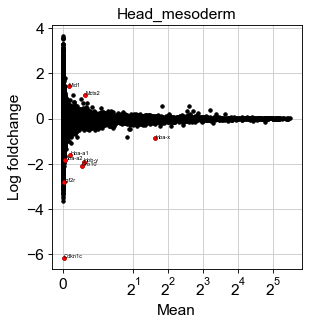

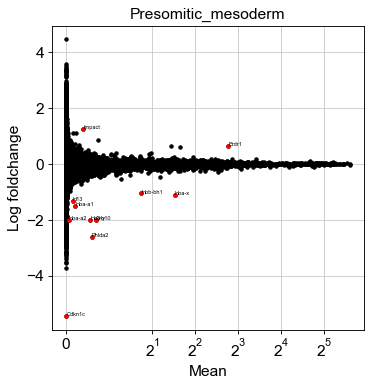

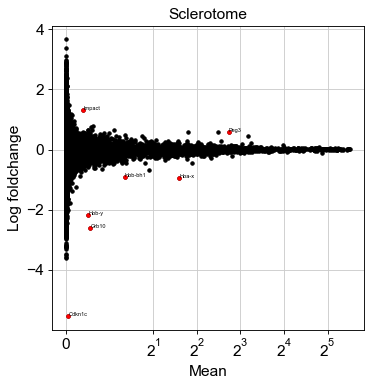

<Figure size 400x400 with 0 Axes>

In [184]:
#MA plots for the celltypes not in WTinjection
for pop in df_good.index:
    print(pop)
    adata_rid = adata[adata.obs['meso.mapped'] == pop,:].copy() 
    sc.tl.rank_genes_groups(adata_rid, groupby='tdTom', groups=['pos','neg'], method='wilcoxon', key = "wilcoxon")
    df1 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['names'])
    df2 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['pvals_adj'])
    df3 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['logfoldchanges'])
    df4 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['scores'])

    df2.index = list(df1.pos)
    df5 = df2.copy()
    df5.index = list(df1.neg)
    df3.index = list(df1.pos)

    df6 = df3.copy()
    df6.index = list(df1.neg)
    
    ## foldchange = []
    mean = []
    foldchange = []
    foldchange_sig = [] #to highlight significant genes
    mean_sig = []
    mean_wti = []
    flc_wti = []
    genes_sig = []


    for i in df2.index[:10000]: #len(adata_rid.var_names
         mean_wt = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'neg',i].X) #mean expression in WT
         mean_ko = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'pos',i].X) #mean expression in KO
         fc = np.log2(mean_ko/mean_wt)    #foldchange
         av = (mean_wt*mean_ko) #average expression
         #av = mean_wt #or just this
         foldchange.append(fc)
         mean.append(av)


         if df2.loc[i][0] < 0.1 and df3.loc[i][0] > 1.5:
             foldchange_sig.append(fc)
             mean_sig.append(av)
             genes_sig.append(i)


    for i in df5.index[:10000]: #len(adata_rid.var_names
         mean_wt = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'neg',i].X) #mean expression in WT
         mean_ko = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'pos',i].X) #mean expression in KO            
         fc1 = np.log2(mean_ko/mean_wt)    #foldchange
         av1 = (mean_ko*mean_wt) #average expression
         #av = mean_wt #or just this
         foldchange.append(fc1)
         mean.append(av1)


         if df5.loc[i][1] < 0.1 and df6.loc[i][1] > 1.5:
             foldchange_sig.append(fc1)
             mean_sig.append(av1)
             genes_sig.append(i)



    #now plot
    plt.plot(mean, foldchange, 'k.')
    plt.plot(mean_sig, foldchange_sig, 'r.') 
    plt.plot(mean_wti, flc_wti, 'v')
    for i in range(len(genes_sig)):
        plt.annotate(genes_sig[i], (mean_sig[i], foldchange_sig[i]), size=5)
    plt.xlabel('Mean')
    plt.ylabel('Log foldchange')
    plt.title(pop)
    plt.xscale('symlog', basex=2)
    texts = []
    plt.savefig(output_dr + '{}'.format(pop)+'_MAplot.png')
    plt.figure(figsize=(5,5))
    #plt.show()            

# Gut subcluster

In [111]:
#only one population passes threshold
df = pd.crosstab(adata.obs['gut_subclust.mapped'], adata.obs['tdTom'])
vec = np.array((df.neg>=50) & (df.pos>=50))
print(vec)
df_good = df.loc[vec] #df.iloc[vec] does not work for one reason I don't understand, but df.loc[voc] takes away index
print(df_good)
print(df_good.dtypes)

[False False False False False False  True]
tdTom                neg  pos
gut_subclust.mapped          
Pharyngeal endoderm  251  131
tdTom
neg    int64
pos    int64
dtype: object


In [106]:
df = pd.crosstab(adata_wt.obs['gut_subclust.mapped'], adata_wt.obs['tdTom'])
vec = np.array((df.neg>=0) & (df.pos>=0))
print(vec)
df_good_wt = df.loc[vec] #df.iloc[vec] does not work for one reason I don't understand, but df.loc[voc] takes away index
print(df_good_wt)
print(df_good_wt.dtypes)

[ True  True  True  True  True  True  True]
tdTom                neg  pos
gut_subclust.mapped          
Foregut 1              5    4
Foregut 2              6   10
Hindgut 1              2    1
Hindgut 2             14   24
Midgut                 7    8
Midgut/Hindgut        24   26
Pharyngeal endoderm   40   44
tdTom
neg    int64
pos    int64
dtype: object


In [112]:
df_good.index = ['Pharyngeal endoderm']

In [114]:
sc.settings.figdir = 'C:/Users/aamw4/home/aamw4/plots/heatmaps/'
ran = range(0,54)
df_dea = pd.DataFrame().reindex(ran) #initialization of df_dea #ValueError: Cannot set a frame with no defined index and a value that cannot be converted to a Series
df_dea.dropna(inplace=True)
number_genes = []


for pop in list(df_good.index):
    print(pop)
    adata_rid = adata[adata.obs['gut_subclust.mapped'] == pop,:].copy()
    sc.tl.rank_genes_groups(adata_rid, groupby='tdTom', groups=['pos','neg'], method='wilcoxon', n_genes=10000, key = "wilcoxon")
    df1 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['names'])
    df2 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['pvals_adj'])
    df3 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['logfoldchanges'])
    df4 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['scores'])

    
    vec_up = np.where((df3['pos']>=np.log2(1.5)) & (df2['pos']<= 0.1) )[0] #alter lfc depending on how many genes you want
    vec_down = np.where((df3['neg']>= np.log2(1.5)) & (df2['neg']<= 0.1) )[0]
    
        
    df_pos = pd.DataFrame(df2.loc[vec_up]['pos'])
    df_pos.index = list(df1.loc[vec_up]['pos'])
    df_pos['lfc'] = list(df3.loc[vec_up]['pos'])
    df_pos = df_pos.sort_values(by='lfc',ascending=False)

 
    df_neg = pd.DataFrame(df2.loc[vec_down]['neg'])
    df_neg.index = list(df1.loc[vec_down]['neg'])
    df_neg['lfc'] = list(df3.loc[vec_down]['neg'])
    df_neg = df_neg.sort_values(by='lfc',ascending=False)

 
    lista_n = df_neg.index
    lista_p = df_pos.index
 
    print(len(lista_p))
    print(len(lista_n))
    
    number_pos = len(lista_p)
    number_neg = len(lista_n)
    
    number_genes.append(number_pos)
    number_genes.append(number_neg)
    
    #make a list with lengths of all lists, sort and take maximum
    
    list_pos = lista_p.tolist() #format to list to add to dataframe
    list_neg = lista_n.tolist()
    
    ##create df_dea with gene names, pvaladj and lfc
           
    df_dea[pop + '_pos_g'] = pd.Series(list_pos) #to avoid errors from different lengths, convert to Series
    df_dea[pop + '_pos_pvaladj'] = pd.Series(list(df_pos['pos']))
    df_dea[pop + '_pos_lfc'] = pd.Series(list(df_pos['lfc']))
    
    
    df_dea[pop + '_neg_g'] = pd.Series(list_neg)
    df_dea[pop + '_neg_pvaladj'] = pd.Series(list(df_neg['neg']))
    df_dea[pop + '_neg_lfc'] = pd.Series(list(df_neg['lfc']))
    
        
print('finished ranking genes')
number_genes.sort(reverse=True)
number_genes[0] #prints highest number of selected genes for any celltype population to adapt range accordingly of df-Dea in initialisation

Pharyngeal endoderm


ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical
... storing 'gut_subclust.mapped' as categorical
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


16
19
finished ranking genes


19

ranking genes
... storing 'haem_subclust.mapped' as categorical
... storing 'meso.mapped' as categorical
... storing 'gut_subclust.mapped' as categorical


Pharyngeal endoderm


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
<ipython-input-115-2a4c701f9bb7>:32: RuntimeWarning: divide by zero encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-115-2a4c701f9bb7>:32: RuntimeWarning: invalid value encountered in double_scalars
  fc = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-115-2a4c701f9bb7>:48: RuntimeWarning: divide by zero encountered in log2
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-115-2a4c701f9bb7>:48: RuntimeWarning: invalid value encountered in double_scalars
  fc1 = np.log2(mean_ko/mean_wt)    #foldchange
<ipython-input-115-2a4c701f9bb7>:71: MatplotlibDeprecationWa

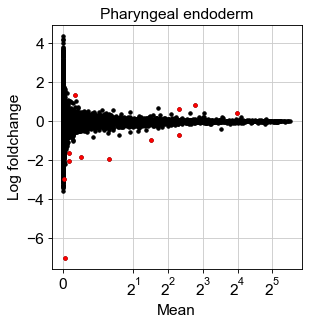

<Figure size 400x400 with 0 Axes>

In [115]:
#MA plots for the celltypes not in WTinjection
for pop in df_good.index:
    print(pop)
    adata_rid = adata[adata.obs['gut_subclust.mapped'] == pop,:].copy() 
    sc.tl.rank_genes_groups(adata_rid, groupby='tdTom', groups=['pos','neg'], method='wilcoxon', key = "wilcoxon")
    df1 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['names'])
    df2 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['pvals_adj'])
    df3 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['logfoldchanges'])
    df4 = pd.DataFrame(adata_rid.uns['rank_genes_groups']['scores'])

    df2.index = list(df1.pos)
    df5 = df2.copy()
    df5.index = list(df1.neg)
    df3.index = list(df1.pos)

    df6 = df3.copy()
    df6.index = list(df1.neg)
    
    ## foldchange = []
    mean = []
    foldchange = []
    foldchange_sig = [] #to highlight significant genes
    mean_sig = []
    mean_wti = []
    flc_wti = []
    genes_sig = []


    for i in df2.index[:10000]: #len(adata_rid.var_names
         mean_wt = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'neg',i].X) #mean expression in WT
         mean_ko = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'pos',i].X) #mean expression in KO
         fc = np.log2(mean_ko/mean_wt)    #foldchange
         av = (mean_wt*mean_ko) #average expression
         #av = mean_wt #or just this
         foldchange.append(fc)
         mean.append(av)


         if df2.loc[i][0] < 0.1 and df3.loc[i][0] > 1.5:
             foldchange_sig.append(fc)
             mean_sig.append(av)
             genes_sig.append(i)


    for i in df5.index[:10000]: #len(adata_rid.var_names
         mean_wt = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'neg',i].X) #mean expression in WT
         mean_ko = np.mean(adata_rid[adata_rid.obs['tdTom'] == 'pos',i].X) #mean expression in KO            
         fc1 = np.log2(mean_ko/mean_wt)    #foldchange
         av1 = (mean_ko*mean_wt) #average expression
         #av = mean_wt #or just this
         foldchange.append(fc1)
         mean.append(av1)


         if df5.loc[i][1] < 0.1 and df6.loc[i][1] > 1.5:
             foldchange_sig.append(fc1)
             mean_sig.append(av1)
             genes_sig.append(i)



    #now plot
    plt.plot(mean, foldchange, 'k.')
    plt.plot(mean_sig, foldchange_sig, 'r.') 
    plt.plot(mean_wti, flc_wti, 'v')
    #for i in range(len(genes_sig)):
        #plt.annotate(genes_sig[i], (mean_sig[i], foldchange_sig[i]), size=5)
    plt.xlabel('Mean')
    plt.ylabel('Log foldchange')
    plt.title(pop)
    plt.xscale('symlog', basex=2)
    texts = []
    plt.savefig(output_dr + '{}'.format(pop)+'_MAplot.png')
    plt.figure(figsize=(5,5))
    #plt.show()            

In [116]:
df_dea.to_csv(output_dr + 'chim_DEGs_final_gut')

# trying to calculate number of genes appearing in several celltype populations

In [ ]:
df_dea = pd.read_csv(out_folder + 'chim_DEGs_df_dea')
df_dea
positive_genes = df_dea.iloc[:, 1::6] #selects every column in 6, here corresponding to pop+pos+gene
positive_genes.dropna()
positive_genes
negative_genes = df_dea.iloc[:, 4::6] #same but for negative genes
negative_genes

In [ ]:
columns_pos = positive_genes.columns
columns_pos = columns_pos.tolist()
columns_neg = negative_genes.columns
columns_neg = columns_neg.tolist()
columns_neg

In [ ]:
unique_genes_pos = pd.unique(positive_genes[['Allantois_pos_g', 'Blood progenitors 1_pos_g', 'Blood progenitors 2_pos_g',
 'Cardiomyocytes_pos_g', 'Caudal Mesoderm_pos_g', 'Def. endoderm_pos_g', 'Erythroid1_pos_g', 'Erythroid2_pos_g',
 'Erythroid3_pos_g',
 'ExE mesoderm_pos_g',
 'Forebrain/Midbrain/Hindbrain_pos_g',
 'Gut_pos_g',
 'Intermediate mesoderm_pos_g',
 'Mesenchyme_pos_g',
 'NMP_pos_g',
 'Neural crest_pos_g',
 'Paraxial mesoderm_pos_g',
 'Pharyngeal mesoderm_pos_g',
 'Somitic mesoderm_pos_g',
 'Spinal cord_pos_g',
 'Surface ectoderm_pos_g']].values.ravel('K')) #list of unique genes across positive_genes dataframe
len(unique_genes_pos)
unique_genes_neg = pd.unique(negative_genes[['Allantois_neg_g',
 'Blood progenitors 1_neg_g',
 'Blood progenitors 2_neg_g',
 'Cardiomyocytes_neg_g',
 'Caudal Mesoderm_neg_g',
 'Def. endoderm_neg_g',
 'Erythroid1_neg_g',
 'Erythroid2_neg_g',
 'Erythroid3_neg_g',
 'ExE mesoderm_neg_g',
 'Forebrain/Midbrain/Hindbrain_neg_g',
 'Gut_neg_g',
 'Intermediate mesoderm_neg_g',
 'Mesenchyme_neg_g',
 'NMP_neg_g',
 'Neural crest_neg_g',
 'Paraxial mesoderm_neg_g',
 'Pharyngeal mesoderm_neg_g',
 'Somitic mesoderm_neg_g',
 'Spinal cord_neg_g',
 'Surface ectoderm_neg_g']].values.ravel('K')) #list of unique genes across positive_genes dataframe

In [ ]:
positive_genes.columns
negative_genes

In [ ]:
#trying to sum occurences of genes in positive_genes

##for every unique gene, for every column go over its contents, add n=+1 every time it encounters it
d=0
lista=[]
columns=list(positive_genes)
for gene in unique_genes_pos: 
    for i in range(len(positive_genes.columns)):
        for j in range(len(positive_genes[positive_genes.columns[i]])):
            if positive_genes.iloc[j,i]==gene:
                d+=1
    lista.append(d)
    d=0
    
print(lista)
len(lista)



In [ ]:
d=0
listb=[]
columns=list(negative_genes)
for gene in unique_genes_neg: 
    for i in range(len(negative_genes.columns)):
        for j in range(len(negative_genes[negative_genes.columns[i]])):
            if negative_genes.iloc[j,i]==gene:
                d+=1
    listb.append(d)
    d=0
    
print(listb)
len(listb)


In [ ]:
#merged_pos = pd.DataFrame(np.column_stack([unique_genes_pos, lista]), 
                             #columns=['genes', 'counts'])
merged_pos = pd.DataFrame({'genes' : unique_genes_pos, 'counts': lista})



merged_pos.set_index('genes', inplace=True)
merged_pos.counts = pd.to_numeric(merged_pos.counts, errors='coerce')
merged_pos.sort_values(by=['counts'], inplace=True, ascending=False)
merged_pos[:30]

In [ ]:
merged_neg = pd.DataFrame(np.column_stack([unique_genes_neg, listb]), 
                               columns=['genes', 'counts'])

merged_neg.set_index('genes', inplace=True)
merged_neg.counts = pd.to_numeric(merged_neg.counts, errors='coerce')
merged_neg.sort_values(by=['counts'], inplace=True, ascending=False)
merged_neg[:30]

# Other method to do the same

In [ ]:
count = pd.Series(positive_genes.squeeze().values.ravel()).value_counts()
counts = pd.DataFrame({'Gene': count.index, 'Count':count.values})
counts[:30]
counts
positivegenes = list(counts['Gene'][:30])

In [ ]:
counts[:50]

In [186]:
len(positivegenes)

NameError: name 'positivegenes' is not defined

In [ ]:
counts.to_csv(out_folder + 'repeated_DEG_positive.csv')

In [ ]:
count = pd.Series(negative_genes.squeeze().values.ravel()).value_counts()
counts = pd.DataFrame({'Gene': count.index, 'Count':count.values})
counts[:30]
negativegenes = list(counts['Gene'][:30])

In [ ]:
counts.to_csv(out_folder + 'repeated_DEG_negative.csv')

# Venn diagrams

In [ ]:
for pop in list_common:
    set1 = set([gene for gene in list(df_chim[pop + '_pos_g'])])
    set2 = set([gene for gene in list(df_wt[pop + '_pos_g'])])
    set3 = set(positivegenes)

    venn3([set1, set2, set3], ('Chimera', 'WT', 'Repeated_genes'))

    plt.show()
    plt.title(pop, fontsize = 20)
    #plt.savefig(out_folder + '{}'.format(pop)+'_VENN_KO.png')

In [ ]:
#absolutely unique genes
ran = range(0,50)
abs_unique_genes = pd.DataFrame(ran)
for pop in list_common:    
    dfn = [gene for gene in list(df_chim[pop + '_neg_g']) if gene not in list(df_wt[pop + '_neg_g']) and gene not in list(negativegenes)]
    dfp = [gene for gene in list(df_chim[pop + '_pos_g']) if gene not in list(df_wt[pop + '_pos_g']) and gene not in list(positivegenes)]
    abs_unique_genes[pop + '_neg_g'] = pd.Series(dfn)
    abs_unique_genes[pop + '_pos_g'] = pd.Series(dfp)
abs_unique_genes

In [ ]:
abs_unique_genes.to_csv(out_folder + 'absolutely_unique_DEGs')

# gene set enrichment analysis

In [ ]:
cl1 = adata[adata.obs['celltype.mapped'] == 'Surface ectoderm',:]
cl1.obs['tdTom'].value_counts()

In [ ]:
#Available databases : ‘Human’, ‘Mouse’, ‘Yeast’, ‘Fly’, ‘Fish’, ‘Worm’ 
gene_set_names = gseapy.get_library_name(database='Human')
print(gene_set_names)

In [ ]:
sc.tl.rank_genes_groups(cl1, groupby="tdTom", method='wilcoxon')
glist = sc.get.rank_genes_groups_df(cl1, group='pos')['names'].squeeze().str.strip().tolist()
print(len(glist))

In [ ]:
#convert to uppercase, necessary for next function
converted_list = [x.upper() for x in glist]
print(converted_list)

In [ ]:
import requests 

In [ ]:
enr_res = gseapy.enrichr(gene_list=converted_list,
                     gene_sets='GO_Biological_Process_2018')
                    
            

In [ ]:
enr = gseapy.enrichr(gene_list=converted_list,
                     organism='Mouse',
                     gene_sets=['GO_Biological_Process_2018'], #GO_Biological_Process_2018
                     description='pathway',
                     cutoff = 0.5)

In [ ]:
enr_res.results.head()

In [ ]:
cl1.raw.X.shape

In [ ]:
# filter for genes that are expressed in more than 5 cells
tmp = cl1.raw.to_adata() 
sc.pp.calculate_qc_metrics(tmp, percent_top=None, log1p=False, inplace=True)
tmp = tmp[:,tmp.var['n_cells_by_counts']>5]